## Predicting CPD Officers Rate of Misconduct

Research Question: 
Can we predict the rate of involvement in misconduct incidents a CPD officer has overall during their career based on officer attributes (i.e. race, gender, age) and network characteristics (i.e. centrality, degree)?

Below is a general outline for this notebook: 

### Exploratory Analysis

1. Download Data and Initial Data Cleaning
2. Select and clean features
3. Create outcome variable and finalize data for model

### Model Exploration

1. Tree-based models with hyperparameter tuning
2. Linear models with hyperparameter tuning
3. Error Analysis

### Model Evaluation

1. Quantitative Measures
2. Discussion of Results

In [1]:
# packages for data
import numpy as np
import pandas as pd
import igraph as ig

import graphviz
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.preprocessing import StandardScaler
from sklearn.preprocessing import MinMaxScaler
from sklearn.preprocessing import OneHotEncoder
from sklearn.model_selection import train_test_split

This project uses data from the Invisible Institute. They have created a large dataset of information on Chicago Police Department officers, including officer demographics, complaints, awards, unit history, and salary information. We will upload three datasets from our data source and only keep the rows and columns we care about (i.e. feature columns and non-null rows). 

Links to data source: 
Invisible Institute website - https://invisible.institute/police-data
Github - https://github.com/invinst/chicago-police-data/tree/master

The first dataframe is the CSV compiling all officers mentioned in the database. Each officer has been assigned a UID which is used to match officers to other dataframes. We are keeping only the columns of the attributes we are interested in, such as age, gender, race, and rank. 

In [2]:
url_officers = "https://media.githubusercontent.com/media/invinst/chicago-police-data/refs/heads/master/data/unified_data/officers/final-profiles.csv"
df_officers = pd.read_csv(
    url_officers,
    dtype={
        "UID": str,
        "appointed_date": str,
        "resignation_date" : str,
        "birth_year": str,
        "gender": str,
        "race" : str,
        "cleaned_rank" : str
        
    })

df_officers = df_officers[["UID", "gender", "race", "birth_year", "appointed_date", "resignation_date", "cleaned_rank"]]
display(df_officers)

C:\Users\uprig\AppData\Local\Temp\ipykernel_62564\283141958.py:2: DtypeWarning: Columns (5) have mixed types. Specify dtype option on import or set low_memory=False.
  df_officers = pd.read_csv(


,UID,gender,race,birth_year,appointed_date,resignation_date,cleaned_rank
0,100001,M,White,1926.0,6/3/50,3/10/80,NaN
1,100002,M,White,1923.0,9/1/56,10/18/79,NaN
2,100003,M,White,1948.0,6/24/68,10/1/80,NaN
3,100004,M,White,1923.0,9/28/53,10/1/80,NaN
4,100005,M,Black,1941.0,6/20/66,9/16/86,POLICE OFFICER
...,...,...,...,...,...,...,...
37540,137568,F,Black,1964.0,12/1/22,12/15/21,INVESTIGATIVE ANALYST
37541,137569,M,Hispanic,1962.0,9/16/19,4/15/17,INFORMATION/MEDIA RETRIEVAL SPECIALIST
37542,137570,F,Black,1956.0,12/16/22,NaN,POLICE ADMINISTRATIVE CLERK
37543,137571,M,Black,1966.0,12/15/23,9/15/23,TRAINING OFFICER


In [3]:
print(df_officers.shape)
null_sum = df_officers.isnull().sum()
null_sum

(37545, 7)


UID                     0
gender                  6
race                  213
birth_year            322
appointed_date        285
resignation_date    12442
cleaned_rank         1142
dtype: int64

A handful of officers do not information on race, gender, age, rank, or appointed date. These will be ignored for now. The high number of officers without a resignation date reflects officers who were still employed at the CPD at the time of dataset creation. 

In the code below, we will calculate the total number of years the officers were at the CPD. For officers without a resignation date, we will replace that column with the latest date of the events included in the data. For them, the number of years worked are years so far as opposed to absolute total. 

In [4]:
# use date columns to calculate number of years worked for CPD
df_officers['appointed_date'] = pd.to_datetime(df_officers['appointed_date'], format='%m/%d/%y', errors='coerce')
df_officers['resignation_date'] = pd.to_datetime(df_officers['resignation_date'], format='%m/%d/%y', errors='coerce')

# For officers who were still working at CPD and have null resignation dates, 
# their resignation date will be replaced with September 15, 2023,
# which is the date of the latest event in the dataset. 
replacement_date = pd.Timestamp('2023-09-15')
df_officers['resignation_date'] = df_officers['resignation_date'].fillna(replacement_date)

# Make sure years converted to the correct century
cutoff = 2026
df_officers['appointed_date'] = df_officers['appointed_date'].apply(lambda x: x.replace(year=x.year - 100) if x.year > cutoff else x)
df_officers['resignation_date'] = df_officers['resignation_date'].apply(lambda x: x.replace(year=x.year - 100) if x.year > cutoff else x)

# Calculate years worked for CPD
df_officers['years_worked'] = (
    df_officers['resignation_date'].dt.year - df_officers['appointed_date'].dt.year
    - (
        (df_officers['resignation_date'].dt.month < df_officers['appointed_date'].dt.month) |
        (
            (df_officers['resignation_date'].dt.month == df_officers['appointed_date'].dt.month) &
            (df_officers['resignation_date'].dt.day < df_officers['appointed_date'].dt.day)
        )
    )
)
df_officers

,UID,gender,race,birth_year,appointed_date,resignation_date,cleaned_rank,years_worked
0,100001,M,White,1926.0,1950-06-03,1980-03-10,NaN,29.0
1,100002,M,White,1923.0,1956-09-01,1979-10-18,NaN,23.0
2,100003,M,White,1948.0,1968-06-24,1980-10-01,NaN,12.0
3,100004,M,White,1923.0,1953-09-28,1980-10-01,NaN,27.0
4,100005,M,Black,1941.0,1966-06-20,1986-09-16,POLICE OFFICER,20.0
...,...,...,...,...,...,...,...,...
37540,137568,F,Black,1964.0,2022-12-01,2021-12-15,INVESTIGATIVE ANALYST,-1.0
37541,137569,M,Hispanic,1962.0,2019-09-16,2017-04-15,INFORMATION/MEDIA RETRIEVAL SPECIALIST,-3.0
37542,137570,F,Black,1956.0,2022-12-16,2023-09-15,POLICE ADMINISTRATIVE CLERK,0.0
37543,137571,M,Black,1966.0,2023-12-15,2023-09-15,TRAINING OFFICER,-1.0


Notice that there are some negative values for the years worked. This is because some officers have resignation dates that are earlier than appointed dates. Since we do not know enough about the data source to determine the reason for this error, we will remove these rows. 

In [5]:
# The data has resignation dates that are earlier than appointed dates for some officers. We will delete these values. 
df_officers = df_officers[df_officers['years_worked'] >= 0].copy()
# Round up 0 values to 1 year
df_officers['years_worked'] = df_officers['years_worked'].replace(0, 1)

The next dataframe is from the CSV that compiles TRR (Tactical Response Reports), which are filled out whenever an officer uses policy-approved force, someone is injured, or someone is allegedly injured. If multiple officers are involved in an event, there is a separate row for each combination of event and officer. We are pulling the columns with officer and event numbers and information on injuries. For the final outcome variable, we will only include incidents where someone was injured as a sign of possible misconduct or excessive force. 

In [6]:
url_trr = "https://media.githubusercontent.com/media/invinst/chicago-police-data/refs/heads/master/data/unified_data/TRR/trr_main.csv"
df_trr = pd.read_csv(
    url_trr,
    dtype={
        "UID": str,
        "event_no": str,
        "trr_date": str,
        "firearm_used": str,
        "subject_injured" : str,
        "subject_alleged_injury" : str
    })
                    
df_trr = df_trr[["UID", "event_no", "trr_date", "firearm_used", "subject_injured", "subject_alleged_injury"]]
df_trr['event_no'] = 'TRR' + df_trr['event_no']
display(df_trr)

C:\Users\uprig\AppData\Local\Temp\ipykernel_62564\1684287357.py:2: DtypeWarning: Columns (4,5,17,19,26,28,34) have mixed types. Specify dtype option on import or set low_memory=False.
  df_trr = pd.read_csv(


,UID,event_no,trr_date,firearm_used,subject_injured,subject_alleged_injury
0,126870.0,TRR401805608.0,1/18/04,0,No,No
1,113572.0,TRR1633012939.0,11/25/16,0,No,No
2,125959.0,TRR1633012939.0,11/25/16,0,No,No
3,132278.0,TRR412508261.0,5/4/04,0,No,Yes
4,103806.0,TRR1702101703.0,1/21/17,0,No,No
...,...,...,...,...,...,...
98859,134201.0,TRR2325812446.0,9/15/23,0,No,Yes
98860,121255.0,TRR2325812446.0,9/15/23,0,No,Yes
98861,135203.0,TRR2325812446.0,9/15/23,0,No,Yes
98862,132575.0,TRR2325815310.0,9/15/23,0,Yes,No


In [7]:
# The TRR datasets has stored the UIDs as doubles, and so they do not exactly match the other datasets. 
# Remove '.0' from the end so UIDs across all datasets match.
df_trr['UID'] = df_trr['UID'].str.replace(r'\.0$', '', regex=True)

For some rows, the event is not assigned a number and there is no information on the officers involved. This information is not helpful to us, so we will remove those rows. 

In [8]:
print(df_trr.shape)
null_sum = df_trr.isnull().sum()
null_sum

(98864, 6)


UID                         809
event_no                  15250
trr_date                      0
firearm_used                  0
subject_injured            1995
subject_alleged_injury     1997
dtype: int64

In [9]:
# Drop rows where either 'UID' or 'event_no' is null
df_trr.dropna(subset=['UID', 'event_no'], inplace=True)
null_sum = df_trr.isnull().sum()
print(null_sum)
print(df_trr.shape)

UID                        0
event_no                   0
trr_date                   0
firearm_used               0
subject_injured           90
subject_alleged_injury    92
dtype: int64
(83229, 6)


The next dataframe is from the CSV that compiles complaints raised against CPD officers. If multiple officers are involved in a complaint, there is a separate row for each combination of complaint and officer. We are pulling the columns with officer and complaint numbers and information on if the officer was disciplined for the incident. 

In [10]:
url_compl = "https://media.githubusercontent.com/media/invinst/chicago-police-data/refs/heads/master/data/unified_data/complaints/complaints-accused.csv"
df_compl = pd.read_csv(
    url_compl,
    dtype={
        "UID": str,
        "cr_id" : str,
        "complaint_category": str,
        "complaint_code": str,
        "disciplined": str
    })
                    
df_compl = df_compl[["UID", "cr_id", "complaint_category", "complaint_code", "disciplined"]]
df_compl['cr_id'] = 'CR' + df_compl['cr_id']
display(df_compl)

C:\Users\uprig\AppData\Local\Temp\ipykernel_62564\3077274809.py:2: DtypeWarning: Columns (7,8,9) have mixed types. Specify dtype option on import or set low_memory=False.
  df_compl = pd.read_csv(


,UID,cr_id,complaint_category,complaint_code,disciplined
0,100162,CR1000002,UNNECESSARY PHYSICAL CONTACT - OFF DUTY,05M,False
1,123177,CR1000002,UNNECESSARY PHYSICAL CONTACT - OFF DUTY,05M,False
2,114991,CR1000004,Excessive Force,05M,True
3,125350,CR1000004,Excessive Force,05M,True
4,131996,CR1000006,Excessive Force,05A,False
...,...,...,...,...,...
263310,129794,CR54286,CONDUCT UNBECOMING (OFF DUTY): JUDICAL PROCESS...,09H,True
263311,106563,CR56104,(DISCONTINUED 1989; SEE CATEGORY 015),02F,True
263312,128757,CR58189,COMMISSION OF CRIME: OTHER FELONY,08M,True
263313,131431,CR58264,COMMISSION OF CRIME: OTHER FELONY,08M,True


For complaints, all rows have numbered incidents and officers involved, so we do not need to remove rows as with the TRR dataframe. There are NA values for the complaint type, but we will not use this, so we will keep those rows. 

In [11]:
print(df_compl.shape)
null_sum = df_compl.isnull().sum()
null_sum

(263315, 5)


UID                      0
cr_id                    0
complaint_category    2887
complaint_code        4021
disciplined              0
dtype: int64

#### Social Network Characteristics

Now, we will create a bipartite social network in order to calculate some social network characteristics for each officer. 

The network is bipartite because it is made up of two types of nodes: officers and incidents. We will create the social network from an edge list. The edge list will be a list of pairs of officers and incidents, where edges exist when an officer is involved in an incident. This is a social network because it reflects associations between officers based on who works together and is involved in cases together. 

In [12]:
# Create edgelist from TRR dataset and rename columns 
edge_list_trr = df_trr[["UID", "event_no"]]
edge_list_trr  = edge_list_trr .rename(columns={"UID" : "officer", "event_no": "incident"})

# Create edgelist from complaints dataset and rename columns 
edge_list_compl = df_compl[["UID","cr_id"]]
edge_list_compl = edge_list_compl.rename(columns={"UID" : "officer","cr_id": "incident"})

#Combine edge lists for TRR and complaints datasets
edge_list_df = pd.concat([edge_list_trr[["officer", "incident"]], edge_list_compl[["officer","incident"]]], ignore_index=True)

# Convert edge list dataframe into bipartitie social network graph
net = ig.Graph.TupleList(
    edge_list_df.itertuples(index=False),
    directed=False
)

# Set types of nodes. Officers = 0, Incident = 1
officer_nodes = set(edge_list_df["officer"])

net.vs["type"] = [
    0 if name in officer_nodes else 1
    for name in net.vs["name"]
]


Now that we have created the biparite network, we will create a projection of the officers. This graph will only include the officer nodes and edges will exist between officers if they have been involved in an incident together. From this graph, we will calculate the following network characteristics for each officer:  degree, centrality (betweenness, closeness, and eigenvector), and the clustering coefficient.

In [13]:
# Create projection of officers
officers_proj, incident_proj = net.bipartite_projection() 

# Calculate node characteristics 
degree = officers_proj.degree()
betweenness = officers_proj.betweenness()
closeness = officers_proj.closeness() 
eigenvector = officers_proj.eigenvector_centrality()
clustering = officers_proj.transitivity_local_undirected()

C:\Users\uprig\AppData\Local\Temp\ipykernel_62564\328671047.py:8: RuntimeWarning: Some eigenvector centralities are nearly zero, indicating that the graph may not be (strongly) connected. Eigenvector centrality is not meaningful for disconnected graphs. Location: src/centrality/eigenvector.c:103
  eigenvector = officers_proj.eigenvector_centrality()


In [14]:
# Create dataframe of node characteristics

net_char = pd.DataFrame({
    "UID" : officers_proj.vs["name"],
    "degree" : degree, 
    "betweenness" : betweenness, 
    "closeness" : closeness, 
    "eigenvector" : eigenvector, 
    "clustering" : clustering
})
net_char

,UID,degree,betweenness,closeness,eigenvector,clustering
0,126870,12,3288.809748,0.257724,2.203506e-04,0.272727
1,113572,53,204888.380029,0.281983,3.382057e-04,0.045718
2,125959,11,8133.628399,0.246627,6.554824e-06,0.109091
3,132278,120,387573.666935,0.314218,3.336914e-03,0.115546
4,103806,27,70818.716686,0.270378,2.022184e-04,0.122507
...,...,...,...,...,...,...
27518,126976,1,0.000000,1.000000,1.255604e-19,NaN
27519,129794,1,0.000000,1.000000,1.282319e-19,NaN
27520,106563,0,0.000000,NaN,-0.000000e+00,NaN
27521,128757,0,0.000000,NaN,-0.000000e+00,NaN


#### Create Final Dataframe

Now we will merge the three dataframes and create the outcome variable column. 


In [15]:
# Create dataframe for model 

# Merge network characteristics dataframe into officers dataframe 
data_df = pd.merge(df_officers, net_char, on="UID", how="left")

# Create new dataframe of officer IDs with if they were ever disciplined for a complaint raised against them
df_compl["disciplined"] = df_compl["disciplined"] == "True"
off_disc = df_compl.groupby("UID", as_index=False)["disciplined"].any()

# Merge discipline dataframe into main dataset
data_df = pd.merge(data_df, off_disc, on="UID", how="left")

##### Create Outcome Variable

Since the total number of incidents will likely be larger for officers who worked for CPD for more years, we will use the ratio between the number of incidents and the number of years as the outcome variable. As mentioned above, only TRR incidents where someone was injured will be included with the complaints. 

The code below creates a new dataframe with counts for each officer of the number of TRR incidents and the number of complaints. From this dataframe, we calculate the total number of incidents for each officer and add this final total to our dataframe. We then calculate the incident rate and create another column in our dataframe. 

In [16]:
# Create outcome variable column and add to dataset

# Calculate the number of complaints for each officer
compl_counts = df_compl.groupby('UID').size().reset_index(name='num_compl')

# Calculate the number of TRR incidents where someone was injured or alleged injured

condition = (df_trr['subject_injured'] == 'Yes') | (df_trr['subject_alleged_injury'] == 'Yes')

trr_counts = (
    df_trr[condition]
    .groupby('UID')
    .size()
    .reset_index(name='num_trr')
)

# Merge both types of counts into one dataframe 
total_counts = pd.merge(trr_counts, compl_counts, on="UID", how = "outer")
total_counts['num_trr'] = total_counts['num_trr'].fillna(0).astype(int)
total_counts['num_compl'] = total_counts['num_compl'].fillna(0).astype(int)

# Create new column with calculated total number of incidents
total_counts['total_incidents'] = total_counts['num_trr'] + total_counts['num_compl']

# Create new dataframe with only the total number of incidents to concatenate 
con_total_counts = total_counts.drop(['num_trr', 'num_compl'], axis=1)

# Merge outcome column into main dataset
data_df = pd.merge(data_df, con_total_counts, on="UID", how="left")

# Calculate rate of incidents based on years employed at CPD
data_df['incident_rate'] = data_df['total_incidents'] / data_df['years_worked']

### Exploratory Analysis

Now that we have created a cleaned dataframe for our source data, we will conduct exploratory analysis and prepare the features for model training. 

In [17]:
# Display NA values
display(data_df.isna().sum())

# Drop all officers who do not have a defined outcome variable (have not been involved in any incidents). 
data_df.dropna(subset=['total_incidents'], inplace=True)
display(data_df.shape)

UID                     0
gender                  0
race                  203
birth_year             47
appointed_date          0
resignation_date        0
cleaned_rank         1054
years_worked            0
degree               9927
betweenness          9927
closeness           11912
eigenvector          9927
clustering          13855
disciplined         10807
total_incidents     10503
incident_rate       10503
dtype: int64

(26659, 16)

In [18]:
display(data_df.head())

,UID,gender,race,birth_year,appointed_date,resignation_date,cleaned_rank,years_worked,degree,betweenness,closeness,eigenvector,clustering,disciplined,total_incidents,incident_rate
5,100006,M,White,1943.0,1971-10-25,2004-03-15,POLICE OFFICER,32.0,2.0,157.312828,0.211903,0.000002,0.000000,False,3.0,0.093750
6,100007,M,Hispanic,1982.0,2009-12-16,2023-09-15,SERGEANT,13.0,24.0,16319.099900,0.264839,0.000108,0.271739,True,28.0,2.153846
7,100008,M,Black,1985.0,2016-06-27,2022-09-30,POLICE OFFICER,6.0,12.0,7937.513139,0.228301,0.000002,0.333333,False,5.0,0.833333
8,100009,M,Black,1975.0,2005-12-05,2023-09-15,POLICE OFFICER,17.0,9.0,28284.195053,0.256478,0.000040,0.250000,False,5.0,0.294118
9,100010,M,Black,1983.0,2013-06-03,2023-09-15,POLICE OFFICER,10.0,12.0,9212.814845,0.244533,0.000005,0.378788,False,4.0,0.400000


#### Data Overview

As of right now, we have 12 features (excluding UID) and 26,659 officers. As we clean the data, our number of samples and features will decrease. 

#### Feature Variables

The data has two types of features: categorical and numerical. We will have four categorical features (race, gender, rank, and discipline) and eight numerical features (degree, betweenness, closeness, eigenvector, clustering, birth year, appointed year, and resignation year). We will now create and clean these features. 

##### Categorical Features

First, the categorical columns need to be converted to the "category" data type. Then, we will check for outliers and convert to one hot encoding. 

In [19]:
# Convert the following columns to categorical data types
cat_col = ['gender', 'race', 'cleaned_rank', 'disciplined']
data_df[cat_col] = data_df[cat_col].astype('category')

##### Outliers

For the categorical features, gender, race, and discipline all have small sets of options. Rank has outlier categories that need to be collapsed or removed. We will take any subcategories for "police officer" and include them in one overall category. We will only keep the main ranks for officers: police officer, sergeant, detective, lieutenant, captain and commander. 

In [20]:
data_df['cleaned_rank'].value_counts().head(20)

cleaned_rank
POLICE OFFICER                                                    17521
SERGEANT                                                           3314
DETECTIVE                                                          2916
LIEUTENANT                                                          894
POLICE OFFICER/FIELD TRAINING OFFICER                               450
POLICE OFFICER ASSIGNED AS EVIDENCE TECHNICIAN                      305
CAPTAIN                                                             276
POLICE OFFICER (PER ARBITRATION AWARD)                              140
COMMANDER                                                           136
POLICE OFFICER ASSIGNED AS EXPLOSIVES DETECTION CANINE HANDLER       78
POLICE OFFICER ASSIGNED AS YOUTH OFFICER                             60
POLICE OFFICER ASSIGNED AS CANINE HANDLER                            54
EXPLOSIVES TECHNICIAN I                                              49
DEPUTY CHIEF                                       

In [21]:
data_df['cleaned_rank'].replace({'POLICE OFFICER/FIELD TRAINING OFFICER': 'POLICE OFFICER',
                                'POLICE OFFICER ASSIGNED AS EVIDENCE TECHNICIAN': 'POLICE OFFICER',
                                'POLICE OFFICER (PER ARBITRATION AWARD)': 'POLICE OFFICER',
                                'POLICE OFFICER ASSIGNED AS EXPLOSIVES DETECTION CANINE HANDLER': 'POLICE OFFICER',
                                'POLICE OFFICER ASSIGNED AS CANINE HANDLER': 'POLICE OFFICER',
                                'POLICE OFFICER/MOUNTED PAT OFFICER': 'POLICE OFFICER',
                                'POLICE OFFICER/MARINE OFFICER': 'POLICE OFFICER',
                                'POLICE OFFICER FORENSIC INVESTIGATOR I': 'POLICE OFFICER', 
                                'POLICE OFFICER ASSIGNED AS SECURITY SPECIALIST': 'POLICE OFFICER'},inplace=True)

C:\Users\uprig\AppData\Local\Temp\ipykernel_62564\2784821173.py:1: FutureWarning: The behavior of Series.replace (and DataFrame.replace) with CategoricalDtype is deprecated. In a future version, replace will only be used for cases that preserve the categories. To change the categories, use ser.cat.rename_categories instead.
  data_df['cleaned_rank'].replace({'POLICE OFFICER/FIELD TRAINING OFFICER': 'POLICE OFFICER',


In [22]:
# remove samples whose "cleaned_rank" belongs to the minority categories
# our criteria here is to remove categories that have less than 10 samples
value_cts = data_df['cleaned_rank'].value_counts()
cat_to_remove = value_cts[value_cts < 100].keys()

print("Data size before dropping minority categories:", data_df.shape)
data_df.drop(data_df[data_df['cleaned_rank'].isin(cat_to_remove)].index, inplace=True)
print("Data size after dropping minority categories:", data_df.shape)

data_df['cleaned_rank'] = data_df['cleaned_rank'].cat.remove_unused_categories()
display(data_df['cleaned_rank'].value_counts())

Data size before dropping minority categories: (26659, 16)
Data size after dropping minority categories: (26303, 16)


cleaned_rank
POLICE OFFICER    18720
SERGEANT           3314
DETECTIVE          2916
LIEUTENANT          894
CAPTAIN             276
COMMANDER           136
Name: count, dtype: int64

##### One Hot Encoding: 

None of the categorical features are ordinal, and all have a low number of options within the category. For these reasons, one hot encoding is the best way to represent the data. 

In [23]:
# Drop all the NA values for the categorical feature columns to prepare for one-hot encoding.
data_df = data_df.dropna(subset=cat_col)

In [24]:
# Initiate a one-hot encoder
ohe = OneHotEncoder(handle_unknown='ignore')
df_cat = data_df[cat_col]
ohe.fit(df_cat)

# # encode the features with the fitted encoder
df_cat_ohe = pd.DataFrame(ohe.transform(df_cat).toarray())

# rename columns to make it expressive
col_names = []
for i in range(len(cat_col)):
    for j in ohe.categories_[i]:
        col_names.append(cat_col[i] + '_' + str(j))

names_dict = {i:col_names[i] for i in range(len(col_names))}
df_cat_ohe.rename(columns=names_dict, inplace=True)
df_cat_ohe.index = data_df.index # add an index column to keep track of each sample

In [25]:
df_cat_ohe.head()

,gender_F,gender_M,race_Asian/Pacific Islander,race_Black,race_Hispanic,race_Native American/Alaskan Native,race_White,cleaned_rank_CAPTAIN,cleaned_rank_COMMANDER,cleaned_rank_DETECTIVE,cleaned_rank_LIEUTENANT,cleaned_rank_POLICE OFFICER,cleaned_rank_SERGEANT,disciplined_0.0,disciplined_1.0
5,0.0,1.0,0.0,0.0,0.0,0.0,1.0,0.0,0.0,0.0,0.0,1.0,0.0,1.0,0.0
6,0.0,1.0,0.0,0.0,1.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0,1.0
7,0.0,1.0,0.0,1.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0,1.0,0.0
8,0.0,1.0,0.0,1.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0,1.0,0.0
9,0.0,1.0,0.0,1.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0,1.0,0.0


##### Numerical Features

Now, we will process the numerical features. First, all columns need to be converted to float. We will change all date columns to year only. Then, we will fill in missing numerical data with the mean value for that feature. Lastly, we will create box plots for each feature and graph the distribution of the feature before and after imputation. 

In [26]:
display(data_df.dtypes)

UID                         object
gender                    category
race                      category
birth_year                  object
appointed_date      datetime64[ns]
resignation_date    datetime64[ns]
cleaned_rank              category
years_worked               float64
degree                     float64
betweenness                float64
closeness                  float64
eigenvector                float64
clustering                 float64
disciplined               category
total_incidents            float64
incident_rate              float64
dtype: object

In [27]:
# Convert birth year to a float
data_df['birth_year'] = pd.to_numeric(data_df['birth_year'], errors='coerce')

# Convert date columns to year only 
data_df['appointed_year'] = data_df['appointed_date'].dt.year.astype(float)
data_df['resignation_year'] = data_df['resignation_date'].dt.year.astype(float)

In [28]:
num_features = ['birth_year', 'appointed_year', 'resignation_year', 'degree', 'betweenness', 'closeness', 'eigenvector', 'clustering']

In [29]:
data_df.isna().sum()

UID                    0
gender                 0
race                   0
birth_year             1
appointed_date         0
resignation_date       0
cleaned_rank           0
years_worked           0
degree                 0
betweenness            0
closeness           1788
eigenvector            0
clustering          3435
disciplined            0
total_incidents        0
incident_rate          0
appointed_year         0
resignation_year       0
dtype: int64

In [30]:
# We will fill in missing values with the mean of that column
#for col in num_features:
        #data_df[col].fillna(value = data_df[col].mean(), inplace=True)

Here is a function we will use to visualize the numerical data using boxplots and distribution histograms. 

In [31]:
# Create a function to clean the numerical data
def clean_numerical(df, col):
    '''takes a dataset df and a column name col as input'''

    # draw boxplot of the column
    plt.figure(figsize=(6, 4));
    sns.boxplot(x=df[col])
    plt.title("Boxplot of %s for Every Officer" % col)
    plt.show();
    plt.clf()

    print(df.shape)

    # visualize the histogram of the cleaned data before imputation
    sns.histplot(df[col], kde=True, bins=20, color="blue")
    plt.title("Distribution of %s Before Imputation" % col)
    plt.show();
    plt.clf()

    df[col].fillna(value = df[col].mean(), inplace=True)
    
    # visualize the histogram of the cleaned data after imputation
    sns.histplot(df[col], kde=True, bins=20, color="blue")
    plt.title("Distribution of %s After Imputation" % col)
    plt.show();
    plt.clf()

    # scale the feature
    scaler = MinMaxScaler()
    df.loc[:, col] = scaler.fit_transform(df[[col]])
    print("Successfully scaled the feature: %s" % col)

    return df

##### Outliers

The box plots below show that there are not outliers for the year columns. However, there are plenty of outliers for the network characteristics. If we were to remove all these outliers, the data will be cut in half. We also want to capture the high variation in the network characteristics to see how they relate to the outcome variable of incident rate. We are prioritizing the interpretability of the model. Therefore, we will keep the outliers in the data for the network characteristics. 

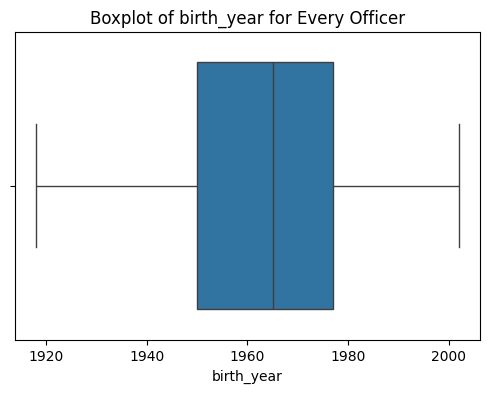

(25854, 18)


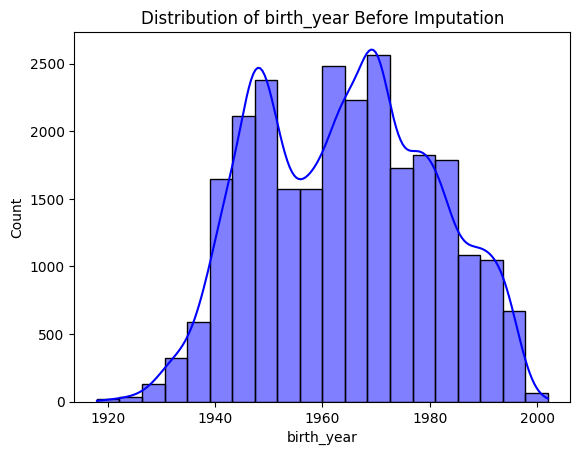

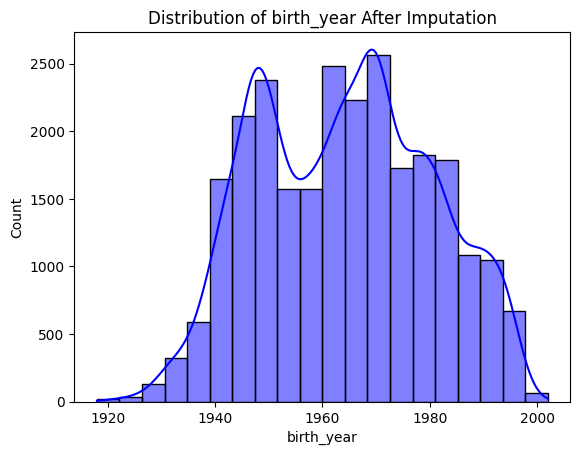

Successfully scaled the feature: birth_year


<Figure size 640x480 with 0 Axes>

In [32]:
data_df = clean_numerical(data_df, col='birth_year')

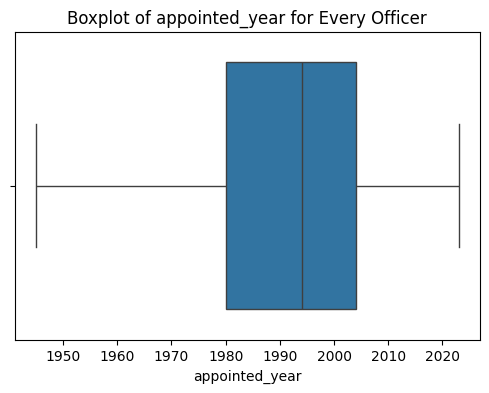

(25854, 18)


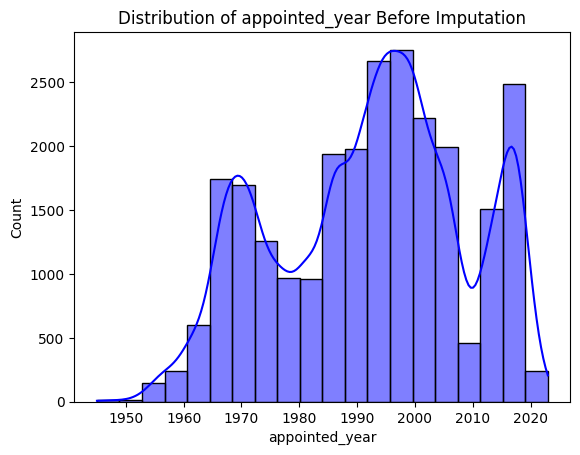

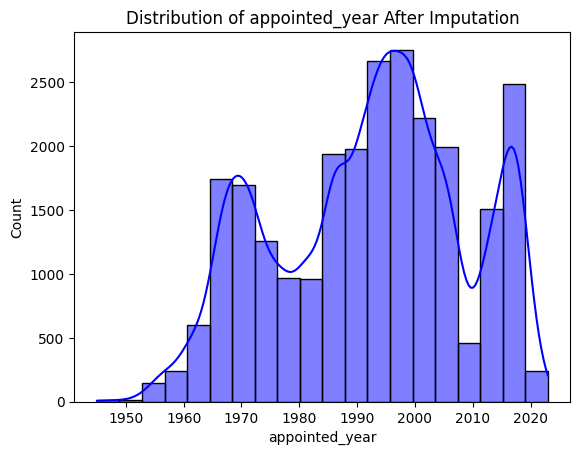

Successfully scaled the feature: appointed_year


<Figure size 640x480 with 0 Axes>

In [33]:
data_df = clean_numerical(data_df, col='appointed_year')

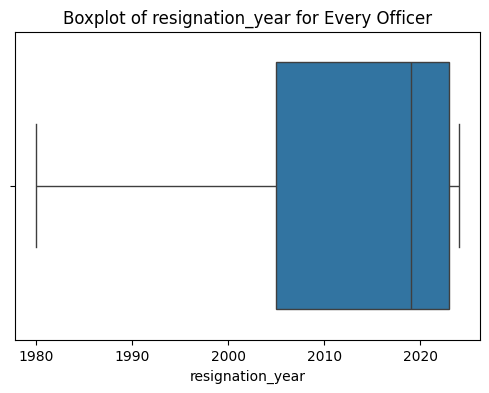

(25854, 18)


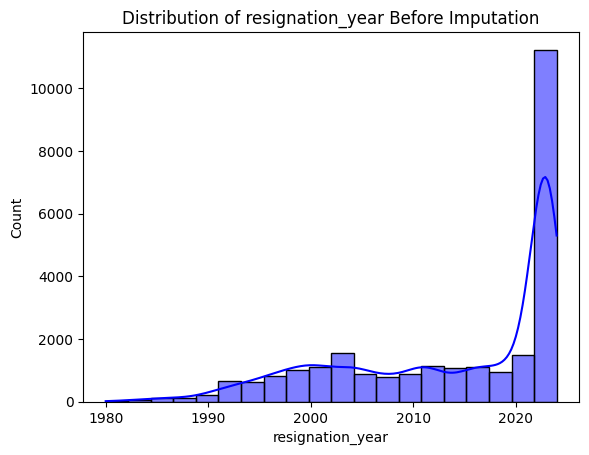

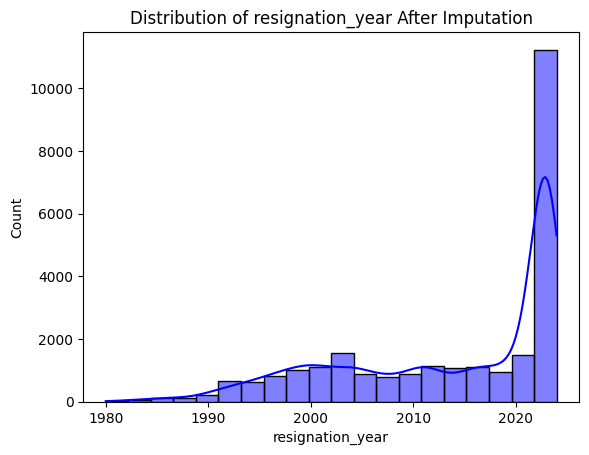

Successfully scaled the feature: resignation_year


<Figure size 640x480 with 0 Axes>

In [34]:
data_df = clean_numerical(data_df, col='resignation_year')

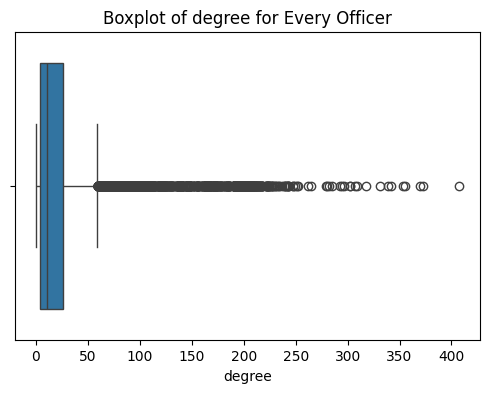

(25854, 18)


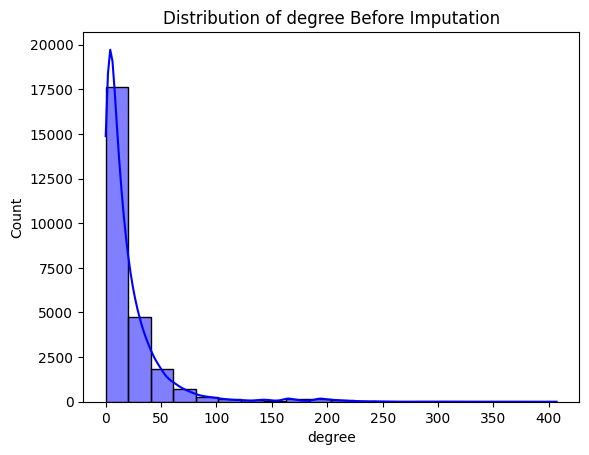

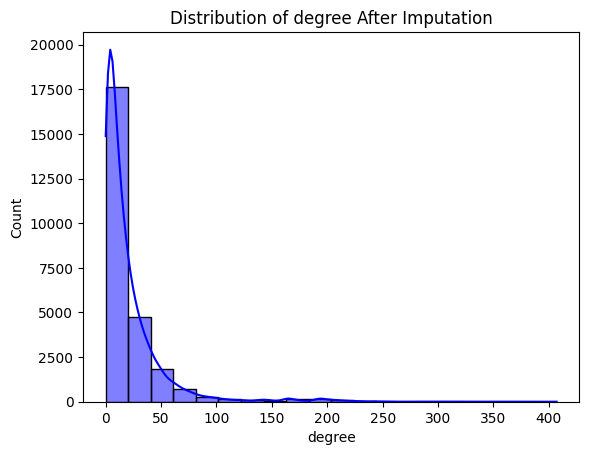

Successfully scaled the feature: degree


<Figure size 640x480 with 0 Axes>

In [35]:
data_df = clean_numerical(data_df, col='degree')

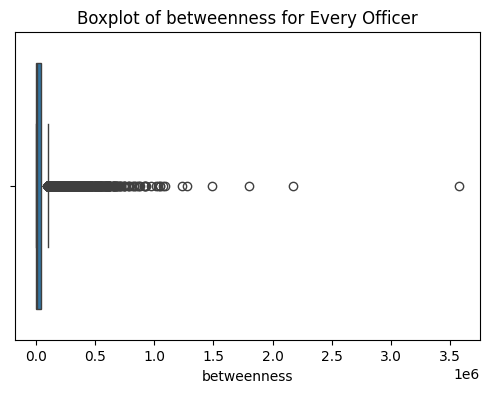

(25854, 18)


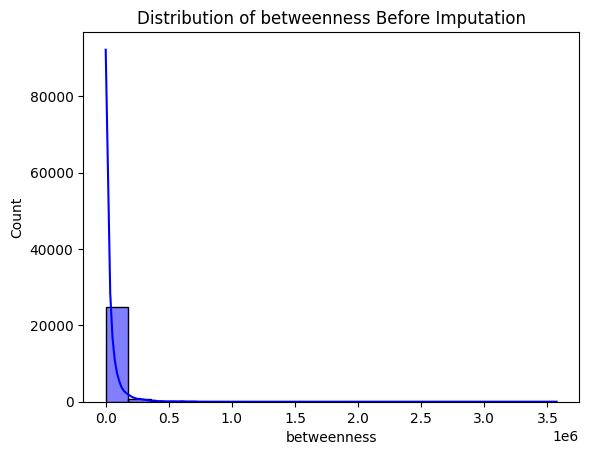

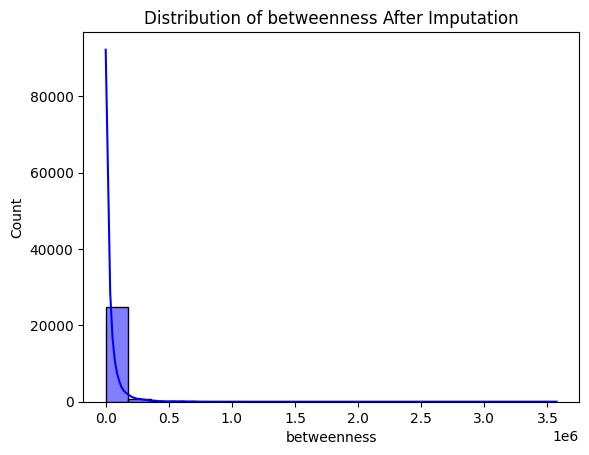

Successfully scaled the feature: betweenness


<Figure size 640x480 with 0 Axes>

In [36]:
data_df = clean_numerical(data_df, col='betweenness')

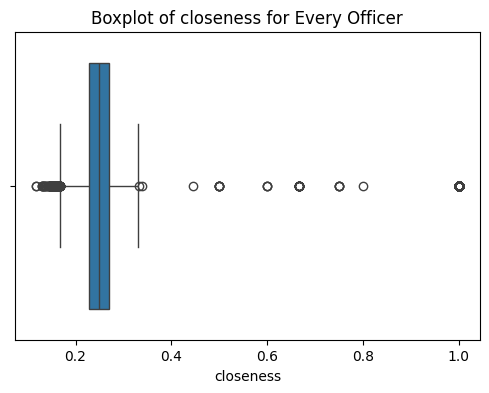

(25854, 18)


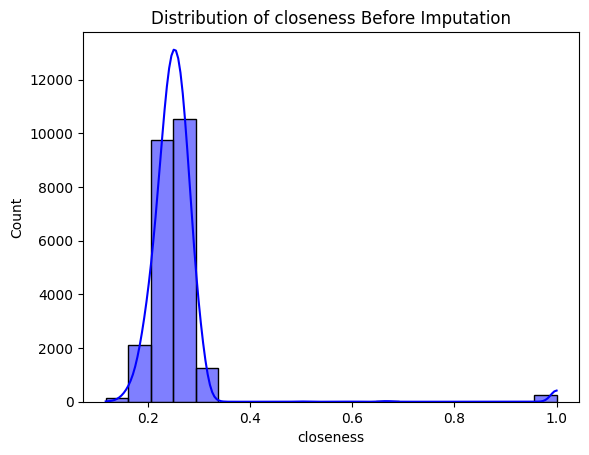

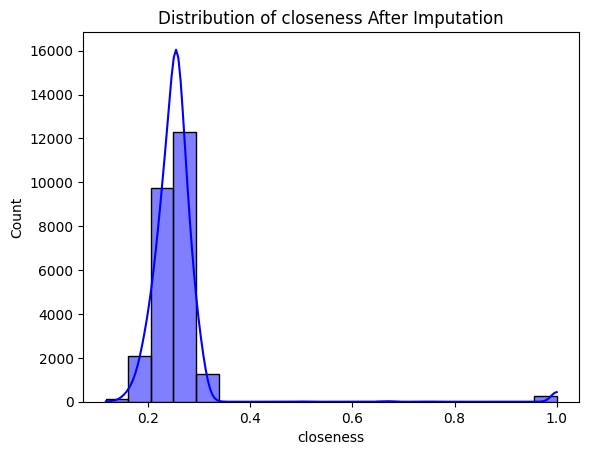

Successfully scaled the feature: closeness


<Figure size 640x480 with 0 Axes>

In [37]:
data_df = clean_numerical(data_df, col='closeness')

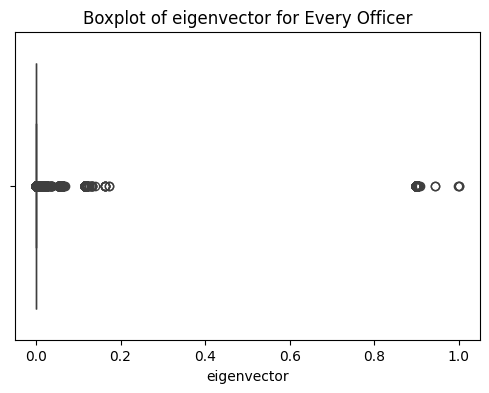

(25854, 18)


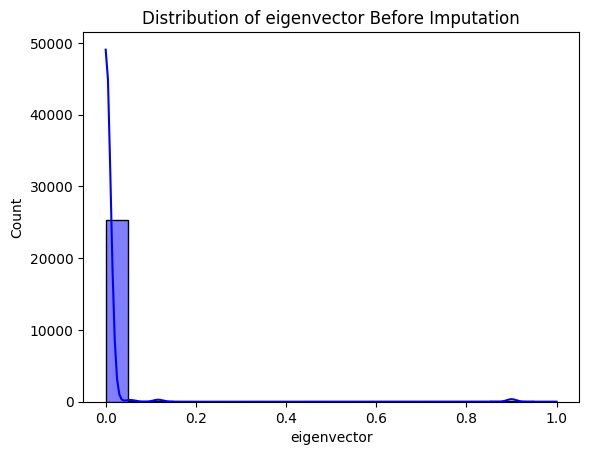

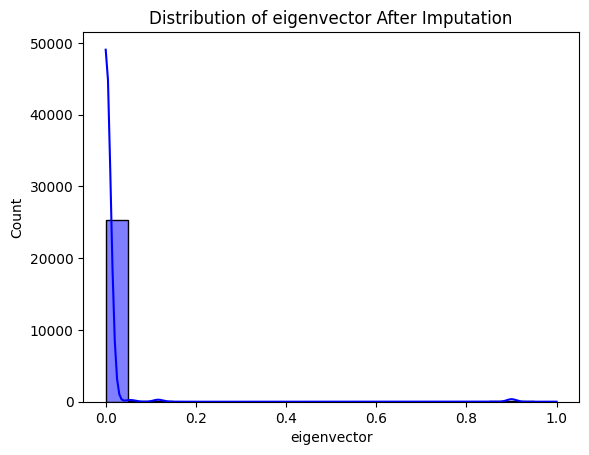

Successfully scaled the feature: eigenvector


<Figure size 640x480 with 0 Axes>

In [38]:
data_df = clean_numerical(data_df, col='eigenvector')

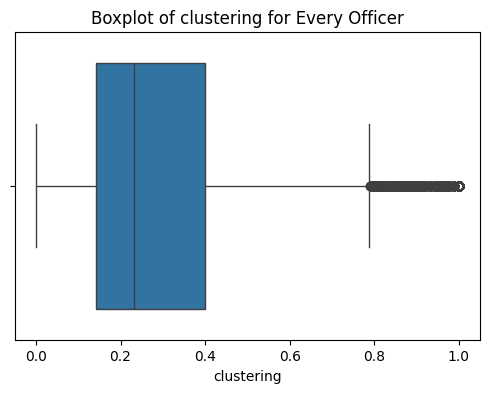

(25854, 18)


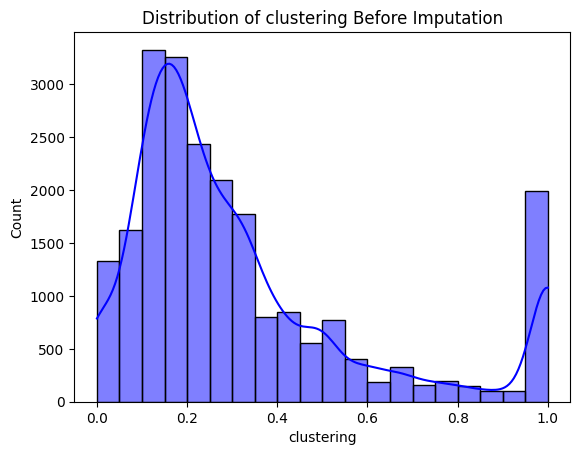

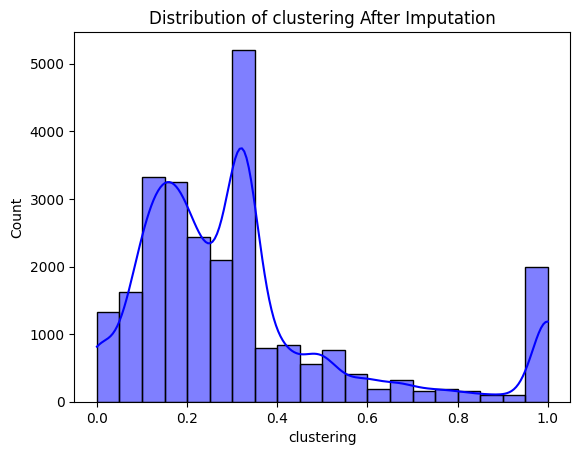

Successfully scaled the feature: clustering


<Figure size 640x480 with 0 Axes>

In [39]:
data_df = clean_numerical(data_df, col='clustering')

The distributions before and after imputation are the same for all features except for clustering. The distribution likely changed for the clustering feature because this network characteristic could not be calculated for many officers, leading to many NA values. The distribution changed only at the mean, where there is now a high spike. This also demonstrates that the clustering feature had a more even distribution, in contrast with eigenvector centrality for example, where most values are in the same bin and so filling in the NAs did not lead to a spike. Even with the change in distribution in centrality, we will keep the imputation because we want the model to have more officers to process. 

##### Heat Map

Below is a heat map to show the correlation values between the numerical features. As we can see below, all three of the year columns are highly correlated with one another. This result makes sense as most officers would follow a typical career trajectory of joining the CPD as young adults and leaving at retirement age. We will keep birth year (as a measure of age) and remove appointed year and resignation year. Some of the network characteristics have higher correlations, but we will still include them in the model. 

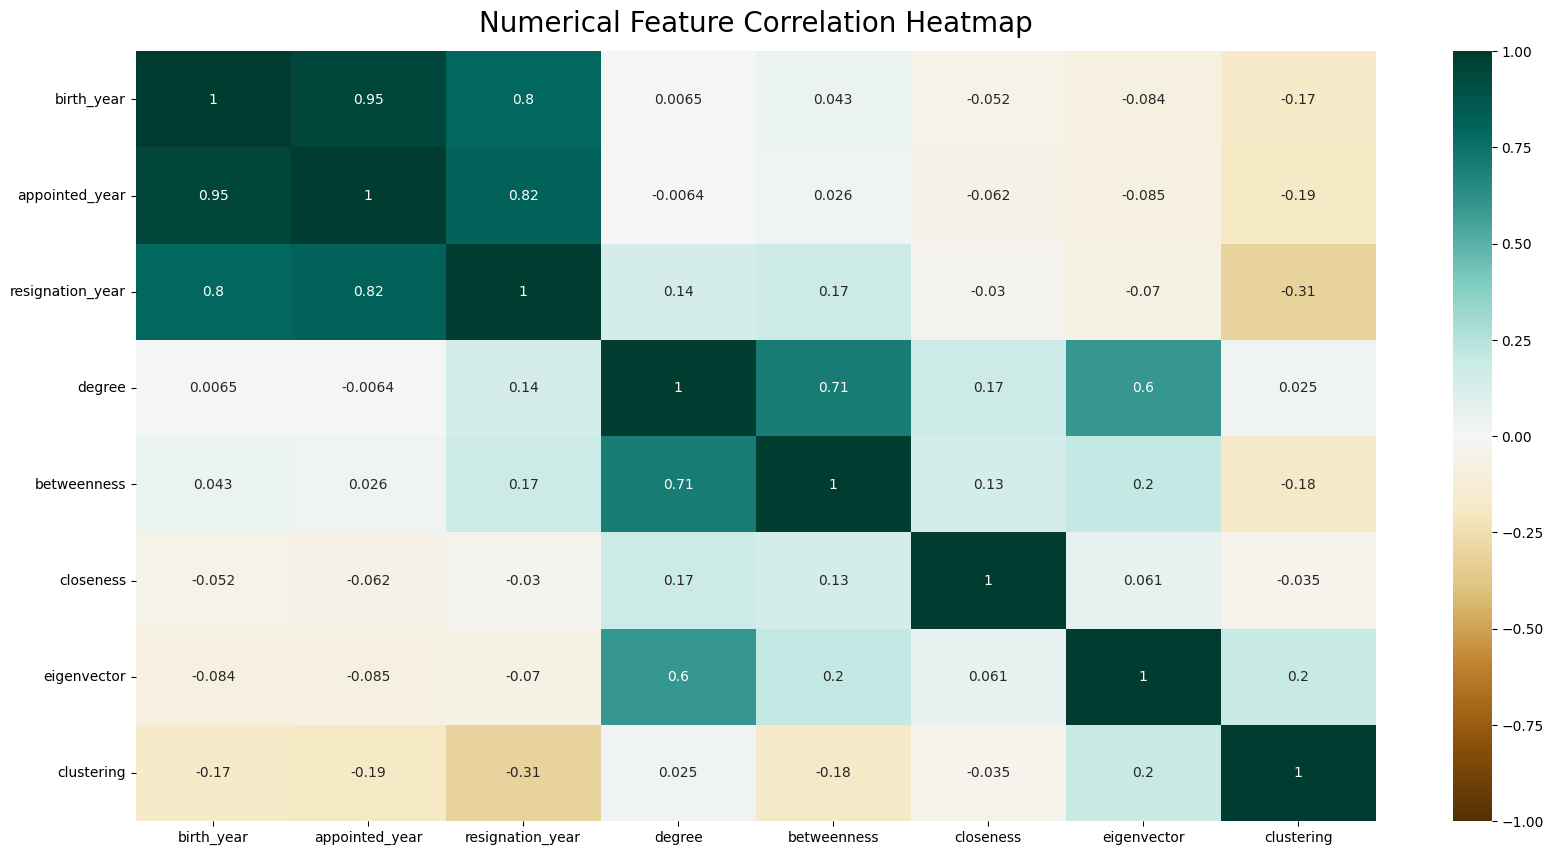

In [40]:
# set the size of the heatmap.
plt.figure(figsize=(20, 10))
heatmap = sns.heatmap(data_df[num_features].corr(), vmin=-1, vmax=1, annot=True, cmap='BrBG')
# Set the title
heatmap.set_title('Numerical Feature Correlation Heatmap', fontdict={'fontsize':20}, pad=14);

In [41]:
# Remove highly correlated values 
num_features.remove('appointed_year')
num_features.remove('resignation_year')

#### Target Variable

Our target variable is incident rate: the ratio of incidients an officer is involved in to the number of years they worked for CPD. Below are some descriptive statistics and the distribution of the variable. Most officers have a relatively low rate of less than one event per year. However, there are many outliers. We want to keep these outliers in the data because we want the model to find patterns to predict what officers are likely to have these abnormal rates. 

In [42]:
data_df['incident_rate'].describe()

count    25854.000000
mean         0.611903
std          0.655237
min          0.021739
25%          0.181818
50%          0.413793
75%          0.814815
max         11.875000
Name: incident_rate, dtype: float64

<Axes: >

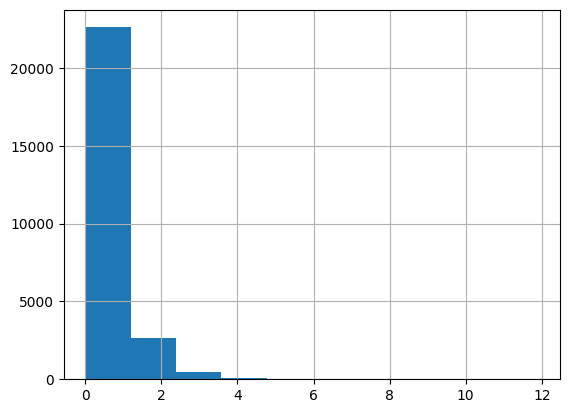

In [43]:
#Check distrbution of Y
data_df.incident_rate.hist(bins = 10)

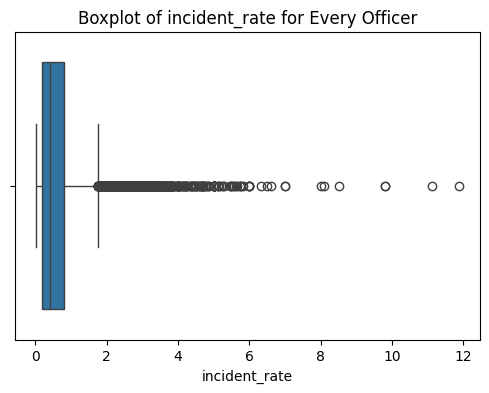

(25854, 18)


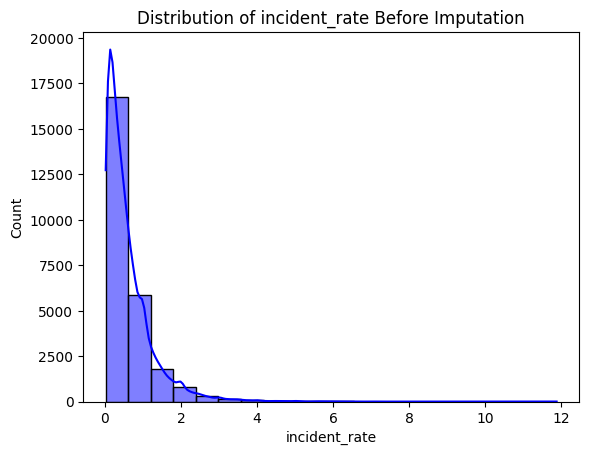

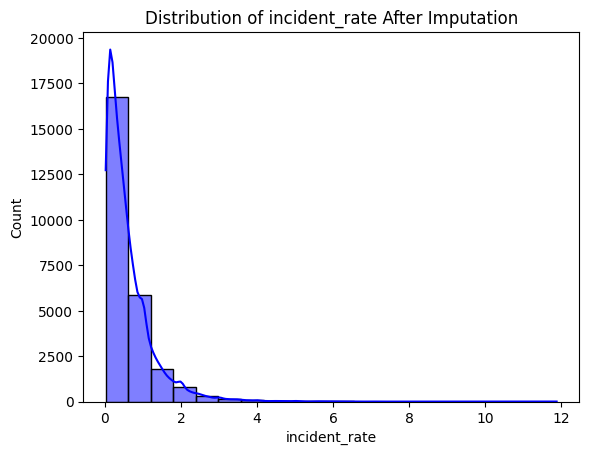

Successfully scaled the feature: incident_rate


<Figure size 640x480 with 0 Axes>

In [44]:
# check for outliers
data_df = clean_numerical(data_df, col='incident_rate')

The distribution of the outcome variable is the same before and after imputation. We now have a finalized dataframe with cleaned feature columns. 

In [45]:
data_df

,UID,gender,race,birth_year,appointed_date,resignation_date,cleaned_rank,years_worked,degree,betweenness,closeness,eigenvector,clustering,disciplined,total_incidents,incident_rate,appointed_year,resignation_year
5,100006,M,White,0.297619,1971-10-25,2004-03-15,POLICE OFFICER,32.0,0.004914,0.000044,0.106993,1.907727e-06,0.000000,False,3.0,0.006075,0.333333,0.545455
6,100007,M,Hispanic,0.761905,2009-12-16,2023-09-15,SERGEANT,13.0,0.058968,0.004568,0.166975,1.075367e-04,0.271739,True,28.0,0.179875,0.820513,0.977273
7,100008,M,Black,0.797619,2016-06-27,2022-09-30,POLICE OFFICER,6.0,0.029484,0.002222,0.125574,1.883234e-06,0.333333,False,5.0,0.068470,0.910256,0.954545
8,100009,M,Black,0.678571,2005-12-05,2023-09-15,POLICE OFFICER,17.0,0.022113,0.007917,0.157502,4.010837e-05,0.250000,False,5.0,0.022979,0.769231,0.977273
9,100010,M,Black,0.773810,2013-06-03,2023-09-15,POLICE OFFICER,10.0,0.029484,0.002579,0.143966,5.045967e-06,0.378788,False,4.0,0.031912,0.871795,0.977273
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
36968,137294,F,Black,0.773810,2022-02-28,2023-09-15,POLICE OFFICER,1.0,0.000000,0.000000,0.157486,0.000000e+00,0.323621,False,1.0,0.082531,0.987179,0.977273
36994,137320,F,White,0.869048,2022-02-28,2023-09-15,POLICE OFFICER,1.0,0.000000,0.000000,0.157486,0.000000e+00,0.323621,False,2.0,0.166896,0.987179,0.977273
36996,137322,M,White,0.880952,2021-12-27,2021-12-28,POLICE OFFICER,1.0,0.000000,0.000000,0.157486,0.000000e+00,0.323621,False,1.0,0.082531,0.974359,0.931818
37000,137326,M,Hispanic,0.952381,2022-08-31,2022-08-31,POLICE OFFICER,1.0,0.000000,0.000000,0.157486,0.000000e+00,0.323621,False,1.0,0.082531,0.987179,0.954545


#### Finalize the Data for Model Training

Our finalized dataframe now has 25,854 officers. We will create the feature matrix and target variable and split our data into training and testing sets. 

In [46]:
# Create feature matrix
X_data = pd.merge(data_df[num_features], df_cat_ohe, left_index=True, right_index=True, how='inner')

feature_names = X_data.columns.to_list()
X_data.shape

(25854, 21)

In [47]:
# Create target variable
y_data = data_df['incident_rate']
y_data.shape

(25854,)

In [48]:
# Split the data into training and testing
train_idx, test_idx = train_test_split(np.arange(data_df.shape[0]), test_size=0.2,
                                       shuffle=True, random_state=42)

len(train_idx), len(test_idx)
print("Number of training examples:{}".format(len(train_idx)))
print("Number of testing examples:{}".format(len(test_idx)))

Number of training examples:20683
Number of testing examples:5171


In [49]:
X_train = X_data.iloc[train_idx]
y_train = y_data.iloc[train_idx]

X_test = X_data.iloc[test_idx]
y_test = y_data.iloc[test_idx]

print("Training data: X_train : {}, y_train : {}".format(X_train.shape, y_train.shape))
print("Testing data: X_test : {}, y_test : {}".format(X_test.shape, y_test.shape))

Training data: X_train : (20683, 21), y_train : (20683,)
Testing data: X_test : (5171, 21), y_test : (5171,)


### Model Exploration and Validation

#### Tree-Based Models

For tree-based models, we will compare the standard DecisionTreeRegressor and the ensemble model RandomForestRegressor. 

#### Linear Modeling

For linear models, we will start with the basic LinearRegression. We will then compare this simple model to Lasso and Ridge models. 


For both types of model, we use GridSearchCV. This combines the process of hyperparameter tuning and cross validation. Hyperparameter tuning tests a variety of hyperparameter combinations to find the best model. Cross validation divides the data into k-folds (in this case, 5) to validate the model on multiple sets of data before the final testing with the test data. 

In [50]:
from sklearn.model_selection import GridSearchCV
from sklearn.tree import DecisionTreeRegressor

In [51]:
dt = DecisionTreeRegressor(random_state=42)

parameters = {'criterion':('absolute_error', 'absolute_error', 'friedman_mse'),
              'max_leaf_nodes':[20, 50, 80, 90, 100, None],
              'max_depth': [5, 8, 10, 15, 20, None]} # 3*6*6 = 108 combinations

grid_cv_dt = GridSearchCV(estimator = dt, param_grid = parameters, cv=5)

grid_cv_dt.fit(X_train, y_train)

,"estimator estimator: estimator objectThis is assumed to implement the scikit-learn estimator interface.Either estimator needs to provide a ``score`` function,or ``scoring`` must be passed.",DecisionTreeR...ndom_state=42)
,"param_grid param_grid: dict or list of dictionariesDictionary with parameters names (`str`) as keys and lists ofparameter settings to try as values, or a list of suchdictionaries, in which case the grids spanned by each dictionaryin the list are explored. This enables searching over any sequenceof parameter settings.","{'criterion': ('absolute_error', ...), 'max_depth': [5, 8, ...], 'max_leaf_nodes': [20, 50, ...]}"
,"scoring scoring: str, callable, list, tuple or dict, default=NoneStrategy to evaluate the performance of the cross-validated model onthe test set.If `scoring` represents a single score, one can use:- a single string (see :ref:`scoring_string_names`);- a callable (see :ref:`scoring_callable`) that returns a single value;- `None`, the `estimator`'s :ref:`default evaluation criterion ` is used.If `scoring` represents multiple scores, one can use:- a list or tuple of unique strings;- a callable returning a dictionary where the keys are the metric names and the values are the metric scores;- a dictionary with metric names as keys and callables as values.See :ref:`multimetric_grid_search` for an example.",None
,"n_jobs n_jobs: int, default=NoneNumber of jobs to run in parallel.``None`` means 1 unless in a :obj:`joblib.parallel_backend` context.``-1`` means using all processors. See :term:`Glossary `for more details... versionchanged:: v0.20 `n_jobs` default changed from 1 to None",None
,"refit refit: bool, str, or callable, default=TrueRefit an estimator using the best found parameters on the wholedataset.For multiple metric evaluation, this needs to be a `str` denoting thescorer that would be used to find the best parameters for refittingthe estimator at the end.Where there are considerations other than maximum score inchoosing a best estimator, ``refit`` can be set to a function whichreturns the selected ``best_index_`` given ``cv_results_``. In thatcase, the ``best_estimator_`` and ``best_params_`` will be setaccording to the returned ``best_index_`` while the ``best_score_``attribute will not be available.The refitted estimator is made available at the ``best_estimator_``attribute and permits using ``predict`` directly on this``GridSearchCV`` instance.Also for multiple metric evaluation, the attributes ``best_index_``,``best_score_`` and ``best_params_`` will only be available if``refit`` is set and all of them will be determined w.r.t this specificscorer.See ``scoring`` parameter to know more about multiple metricevaluation.See :ref:`sphx_glr_auto_examples_model_selection_plot_grid_search_digits.py`to see how to design a custom selection strategy using a callablevia `refit`.See :ref:`this example`for an example of how to use ``refit=callable`` to balance modelcomplexity and cross-validated score... versionchanged:: 0.20 Support for callable added.",True
,"cv cv: int, cross-validation generator or an iterable, default=NoneDetermines the cross-validation splitting strategy.Possible inputs for cv are:- None, to use the default 5-fold cross validation,- integer, to specify the number of folds in a `(Stratified)KFold`,- :term:`CV splitter`,- An iterable yielding (train, test) splits as arrays of indices.For integer/None inputs, if the estimator is a classifier and ``y`` iseither binary or multiclass, :class:`StratifiedKFold` is used. In allother cases, :class:`KFold` is used. These splitters are instantiatedwith `shuffle=False` so the splits will be the same across calls.Refer :ref:`User Guide ` for the variouscross-validation strategies that can be used here... versionchanged:: 0.22 ``cv`` default value if None changed from 3-fold to 5-fold.",5
,"verbose verbose: intControls the verbosity: the higher, the more messages.- >1 : the computation time for each fold and parameter candidate is displayed;

In [52]:
best_dt_reg = grid_cv_dt.best_estimator_
grid_cv_dt.best_estimator_

,"criterion criterion: {""squared_error"", ""friedman_mse"", ""absolute_error"", ""poisson""}, default=""squared_error""The function to measure the quality of a split. Supported criteriaare ""squared_error"" for the mean squared error, which is equal tovariance reduction as feature selection criterion and minimizes the L2loss using the mean of each terminal node, ""friedman_mse"", which usesmean squared error with Friedman's improvement score for potentialsplits, ""absolute_error"" for the mean absolute error, which minimizesthe L1 loss using the median of each terminal node, and ""poisson"" whichuses reduction in the half mean Poisson deviance to find splits... versionadded:: 0.18 Mean Absolute Error (MAE) criterion... versionadded:: 0.24 Poisson deviance criterion.",'absolute_error'
,"splitter splitter: {""best"", ""random""}, default=""best""The strategy used to choose the split at each node. Supportedstrategies are ""best"" to choose the best split and ""random"" to choosethe best random split.",'best'
,"max_depth max_depth: int, default=NoneThe maximum depth of the tree. If None, then nodes are expanded untilall leaves are pure or until all leaves contain less thanmin_samples_split samples.For an example of how ``max_depth`` influences the model, see:ref:`sphx_glr_auto_examples_tree_plot_tree_regression.py`.",10
,"min_samples_split min_samples_split: int or float, default=2The minimum number of samples required to split an internal node:- If int, then consider `min_samples_split` as the minimum number.- If float, then `min_samples_split` is a fraction and `ceil(min_samples_split * n_samples)` are the minimum number of samples for each split... versionchanged:: 0.18 Added float values for fractions.",2
,"min_samples_leaf min_samples_leaf: int or float, default=1The minimum number of samples required to be at a leaf node.A split point at any depth will only be considered if it leaves atleast ``min_samples_leaf`` training samples in each of the left andright branches. This may have the effect of smoothing the model,especially in regression.- If int, then consider `min_samples_leaf` as the minimum number.- If float, then `min_samples_leaf` is a fraction and `ceil(min_samples_leaf * n_samples)` are the minimum number of samples for each node... versionchanged:: 0.18 Added float values for fractions.",1
,"min_weight_fraction_leaf min_weight_fraction_leaf: float, default=0.0The minimum weighted fraction of the sum total of weights (of allthe input samples) required to be at a leaf node. Samples haveequal weight when sample_weight is not provided.",0.0
,"max_features max_features: int, float or {""sqrt"", ""log2""}, default=NoneThe number of features to consider when looking for the best split:- If int, then consider `max_features` features at each split.- If float, then `max_features` is a fraction and `max(1, int(max_features * n_features_in_))` features are considered at each split.- If ""sqrt"", then `max_features=sqrt(n_features)`.- If ""log2"", then `max_features=log2(n_features)`.- If None, then `max_features=n_features`.Note: the search for a split does not stop until at least onevalid partition of the node samples is found, even if it requires toeffectively inspect more than ``max_features`` features.",None
,"random_state random_state: int, RandomState instance or None, default=NoneControls the randomness of the estimator. The features are alwaysrandomly permuted at each split, even if ``splitter`` is set to``""best""``. When ``max_features < n_features``, the algorithm willselect ``max_features`` at random at each split before finding the bestsplit among them. But the best found split may vary across differentruns, even if ``max_features=n_features``. That is the case, if theimprovement of the criterion is identical for several splits and onesplit has to be selected at random. To obtain a deterministic behaviourduring fitting, ``random_state`` has to be fixed to an integer.See :term:`Glossary ` for details.",42
,"max_le

In [53]:
grid_cv_dt.best_score_

np.float64(0.3777567096943638)

In [54]:
grid_cv_dt.score(X_test, y_test)

0.3379947074667632

During validation, the best score was 0.38. On the testing data, the model has an lower R2 value of 0.34.

Below, we visualize the tree for the DecisionTreeRegressor. It is a very wide tree due to the max depth being cut off at 10. 

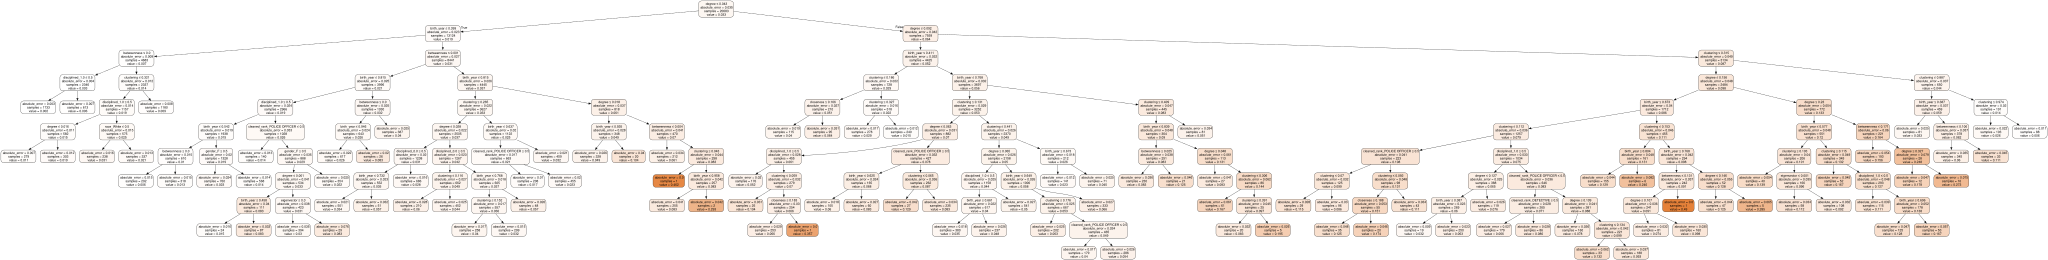

In [55]:
from sklearn import tree

dot_data = tree.export_graphviz(best_dt_reg, out_file=None,
                                feature_names=feature_names,
                                class_names=["popularity"],
                                filled=True, rounded=True,
                                special_characters=True)
graph = graphviz.Source(dot_data)
graph

In [56]:
# Table with feature importances
data = {"features": feature_names, "importances" : np.round(best_dt_reg.feature_importances_,2)}
feat_impor_dtc = pd.DataFrame(data)
feat_impor_dtc.sort_values(by = 'importances', ascending = False)

,features,importances
1,degree,0.51
0,birth_year,0.25
5,clustering,0.13
2,betweenness,0.07
20,disciplined_1.0,0.02
17,cleaned_rank_POLICE OFFICER,0.01
3,closeness,0.00
4,eigenvector,0.00
6,gender_F,0.00
9,race_Black,0.00


For the DecisionTreeRegressor, the features with the highest importance are degree, birth_year, and clustering. Degree and clustering both reflect how well connected an officer is with other officers. This means there are patterns between incident involvement and being well connected to other officers. There are also patterns depending on the age of the officer. Age could impact rate of incidents if there are certain time periods where the culture at CPD allowed misconduct and complaints to occur at a higher rate. Race, rank, and gender have little impact on the model. The rank of police officer has a slightly stronger coefficient than the other ranks, which would make sense as police officers have the most contact with the public and so are likely to be the receiver of complaints. 

##### Random Forest Regressor

In [57]:
from sklearn.ensemble import RandomForestRegressor

In [58]:
rf = RandomForestRegressor(random_state=42)

parameters = {'criterion':('absolute_error', 'absolute_error', 'friedman_mse'),
              'max_depth': [5, 8, 10, 15, 20, None]} # 3*6 = 18 combinations

grid_cv_rf = GridSearchCV(estimator = rf, param_grid = parameters, cv=5)

grid_cv_rf.fit(X_train, y_train)

,"estimator estimator: estimator objectThis is assumed to implement the scikit-learn estimator interface.Either estimator needs to provide a ``score`` function,or ``scoring`` must be passed.",RandomForestR...ndom_state=42)
,"param_grid param_grid: dict or list of dictionariesDictionary with parameters names (`str`) as keys and lists ofparameter settings to try as values, or a list of suchdictionaries, in which case the grids spanned by each dictionaryin the list are explored. This enables searching over any sequenceof parameter settings.","{'criterion': ('absolute_error', ...), 'max_depth': [5, 8, ...]}"
,"scoring scoring: str, callable, list, tuple or dict, default=NoneStrategy to evaluate the performance of the cross-validated model onthe test set.If `scoring` represents a single score, one can use:- a single string (see :ref:`scoring_string_names`);- a callable (see :ref:`scoring_callable`) that returns a single value;- `None`, the `estimator`'s :ref:`default evaluation criterion ` is used.If `scoring` represents multiple scores, one can use:- a list or tuple of unique strings;- a callable returning a dictionary where the keys are the metric names and the values are the metric scores;- a dictionary with metric names as keys and callables as values.See :ref:`multimetric_grid_search` for an example.",None
,"n_jobs n_jobs: int, default=NoneNumber of jobs to run in parallel.``None`` means 1 unless in a :obj:`joblib.parallel_backend` context.``-1`` means using all processors. See :term:`Glossary `for more details... versionchanged:: v0.20 `n_jobs` default changed from 1 to None",None
,"refit refit: bool, str, or callable, default=TrueRefit an estimator using the best found parameters on the wholedataset.For multiple metric evaluation, this needs to be a `str` denoting thescorer that would be used to find the best parameters for refittingthe estimator at the end.Where there are considerations other than maximum score inchoosing a best estimator, ``refit`` can be set to a function whichreturns the selected ``best_index_`` given ``cv_results_``. In thatcase, the ``best_estimator_`` and ``best_params_`` will be setaccording to the returned ``best_index_`` while the ``best_score_``attribute will not be available.The refitted estimator is made available at the ``best_estimator_``attribute and permits using ``predict`` directly on this``GridSearchCV`` instance.Also for multiple metric evaluation, the attributes ``best_index_``,``best_score_`` and ``best_params_`` will only be available if``refit`` is set and all of them will be determined w.r.t this specificscorer.See ``scoring`` parameter to know more about multiple metricevaluation.See :ref:`sphx_glr_auto_examples_model_selection_plot_grid_search_digits.py`to see how to design a custom selection strategy using a callablevia `refit`.See :ref:`this example`for an example of how to use ``refit=callable`` to balance modelcomplexity and cross-validated score... versionchanged:: 0.20 Support for callable added.",True
,"cv cv: int, cross-validation generator or an iterable, default=NoneDetermines the cross-validation splitting strategy.Possible inputs for cv are:- None, to use the default 5-fold cross validation,- integer, to specify the number of folds in a `(Stratified)KFold`,- :term:`CV splitter`,- An iterable yielding (train, test) splits as arrays of indices.For integer/None inputs, if the estimator is a classifier and ``y`` iseither binary or multiclass, :class:`StratifiedKFold` is used. In allother cases, :class:`KFold` is used. These splitters are instantiatedwith `shuffle=False` so the splits will be the same across calls.Refer :ref:`User Guide ` for the variouscross-validation strategies that can be used here... versionchanged:: 0.22 ``cv`` default value if None changed from 3-fold to 5-fold.",5
,"verbose verbose: intControls the verbosity: the higher, the more messages.- >1 : the computation time for each fold and parameter candidate is displayed;- >2 : the score is also displaye

In [59]:
best_rf_reg = grid_cv_rf.best_estimator_
grid_cv_rf.best_estimator_

,"n_estimators n_estimators: int, default=100The number of trees in the forest... versionchanged:: 0.22 The default value of ``n_estimators`` changed from 10 to 100 in 0.22.",100
,"criterion criterion: {""squared_error"", ""absolute_error"", ""friedman_mse"", ""poisson""}, default=""squared_error""The function to measure the quality of a split. Supported criteriaare ""squared_error"" for the mean squared error, which is equal tovariance reduction as feature selection criterion and minimizes the L2loss using the mean of each terminal node, ""friedman_mse"", which usesmean squared error with Friedman's improvement score for potentialsplits, ""absolute_error"" for the mean absolute error, which minimizesthe L1 loss using the median of each terminal node, and ""poisson"" whichuses reduction in Poisson deviance to find splits.Training using ""absolute_error"" is significantly slowerthan when using ""squared_error""... versionadded:: 0.18 Mean Absolute Error (MAE) criterion... versionadded:: 1.0 Poisson criterion.",'friedman_mse'
,"max_depth max_depth: int, default=NoneThe maximum depth of the tree. If None, then nodes are expanded untilall leaves are pure or until all leaves contain less thanmin_samples_split samples.",10
,"min_samples_split min_samples_split: int or float, default=2The minimum number of samples required to split an internal node:- If int, then consider `min_samples_split` as the minimum number.- If float, then `min_samples_split` is a fraction and `ceil(min_samples_split * n_samples)` are the minimum number of samples for each split... versionchanged:: 0.18 Added float values for fractions.",2
,"min_samples_leaf min_samples_leaf: int or float, default=1The minimum number of samples required to be at a leaf node.A split point at any depth will only be considered if it leaves atleast ``min_samples_leaf`` training samples in each of the left andright branches. This may have the effect of smoothing the model,especially in regression.- If int, then consider `min_samples_leaf` as the minimum number.- If float, then `min_samples_leaf` is a fraction and `ceil(min_samples_leaf * n_samples)` are the minimum number of samples for each node... versionchanged:: 0.18 Added float values for fractions.",1
,"min_weight_fraction_leaf min_weight_fraction_leaf: float, default=0.0The minimum weighted fraction of the sum total of weights (of allthe input samples) required to be at a leaf node. Samples haveequal weight when sample_weight is not provided.",0.0
,"max_features max_features: {""sqrt"", ""log2"", None}, int or float, default=1.0The number of features to consider when looking for the best split:- If int, then consider `max_features` features at each split.- If float, then `max_features` is a fraction and `max(1, int(max_features * n_features_in_))` features are considered at each split.- If ""sqrt"", then `max_features=sqrt(n_features)`.- If ""log2"", then `max_features=log2(n_features)`.- If None or 1.0, then `max_features=n_features`... note:: The default of 1.0 is equivalent to bagged trees and more randomness can be achieved by setting smaller values, e.g. 0.3... versionchanged:: 1.1 The default of `max_features` changed from `""auto""` to 1.0.Note: the search for a split does not stop until at least onevalid partition of the node samples is found, even if it requires toeffectively inspect more than ``max_features`` features.",1.0
,"max_leaf_nodes max_leaf_nodes: int, default=NoneGrow trees with ``max_leaf_nodes`` in best-first fashion.Best nodes are defined as relative reduction in impurity.If None then unlimited number of leaf nodes.",None
,"min_impurity_decrease min_impurity_decrease: float, default=0.0A node will be split if this split induces a decrease of the impuritygreater than or equal to this value.The weighted impurity decrease equation is the following:: N_t / N * (impurity - N_t_R / N_t * right_impurity - N_t_L / N_t * left_impurity)where ``N`` is the total number of samples, ``N_t`` is the number ofsamples a

In [60]:
grid_cv_rf.best_score_

np.float64(0.4634005993313998)

In [61]:
grid_cv_rf.score(X_test, y_test)

0.4309363226614157

The best score from validation is 0.46 and the score on the testing data is 0.43. Like DecisionTreeRegressor, there is a slight decrease in the R2 score on training. 

In [62]:
# Table with feature importances
data = {"features": feature_names, "importances" : np.round(best_rf_reg.feature_importances_,2)}
feat_impor_dtc = pd.DataFrame(data)
feat_impor_dtc.sort_values(by = 'importances', ascending = False)

,features,importances
1,degree,0.34
0,birth_year,0.20
2,betweenness,0.15
5,clustering,0.13
3,closeness,0.06
4,eigenvector,0.04
20,disciplined_1.0,0.02
17,cleaned_rank_POLICE OFFICER,0.02
6,gender_F,0.01
9,race_Black,0.01


For the RandomForestRegressor, the features with the highest importance are degree and birth_year, which is the same as with the DecisionTreeRegressor. However, instead of clustering, RandomForestRegressor has betweenness as the third most important. For this model, Black and female have a small impact on the model, as opposed to 0 coefficients in the previous model. 

The possible reasoning for the importance of features is the same as with the DecisionTreeRegressor. 

RandomForestRegressor is a slightly better model than DecisionTreeRegressor when comparing the R2 scores. This makes sense as RandomForestRegressor is an ensemble model and uses randomization to aggregate possibilities with different combinations of features and sampling. 

##### Linear Regression

For this model, we will leave the default parameters, and explore different parameters for Lasso and Ridge. LinearRegression performs relatively well on its own and better than Lasso. It has similar top features to the tree-based models: betweenness, degree, eigenvector, and birth_year. 

In [63]:
from sklearn.linear_model import LinearRegression

In [64]:
ln_reg = LinearRegression()
ln_reg.fit(X_train, y_train)
float("{:.3f}".format(ln_reg.score(X_test, y_test))) # the R2 score

0.359

In [65]:
importance = pd.DataFrame({
    'feature': feature_names,
    'coefficient': ln_reg.coef_
}).sort_values(by='coefficient', key=abs, ascending=False)
importance

,feature,coefficient
2,betweenness,0.443483
1,degree,0.223620
4,eigenvector,-0.126969
0,birth_year,0.088698
5,clustering,-0.030282
17,cleaned_rank_POLICE OFFICER,0.011735
19,disciplined_0.0,-0.008046
20,disciplined_1.0,0.008046
6,gender_F,-0.007434
7,gender_M,0.007434


##### Lasso

This model is the worst out of all the models, and is often zero regardless of the alpha value. Again, the model performs slightly worse on the testing data than the best score on the validation data. Similar to the tree models, birth year, degree, and clustering are significant features. Interestingly, gender and if an officer is white have coefficients while most features have zero coefficients. This breaks with the trend of race and gender having little proportional effect on the model. 

In [66]:
from sklearn.linear_model import Lasso

In [67]:
lr1 = Lasso()

parameters = {'alpha' : [1, 0.1, 0.01, 0.001, 10, 100]}

grid_cv_lr1 = GridSearchCV(estimator = lr1, param_grid = parameters, cv=5)

grid_cv_lr1.fit(X_train, y_train)

,"estimator estimator: estimator objectThis is assumed to implement the scikit-learn estimator interface.Either estimator needs to provide a ``score`` function,or ``scoring`` must be passed.",Lasso()
,"param_grid param_grid: dict or list of dictionariesDictionary with parameters names (`str`) as keys and lists ofparameter settings to try as values, or a list of suchdictionaries, in which case the grids spanned by each dictionaryin the list are explored. This enables searching over any sequenceof parameter settings.","{'alpha': [1, 0.1, ...]}"
,"scoring scoring: str, callable, list, tuple or dict, default=NoneStrategy to evaluate the performance of the cross-validated model onthe test set.If `scoring` represents a single score, one can use:- a single string (see :ref:`scoring_string_names`);- a callable (see :ref:`scoring_callable`) that returns a single value;- `None`, the `estimator`'s :ref:`default evaluation criterion ` is used.If `scoring` represents multiple scores, one can use:- a list or tuple of unique strings;- a callable returning a dictionary where the keys are the metric names and the values are the metric scores;- a dictionary with metric names as keys and callables as values.See :ref:`multimetric_grid_search` for an example.",None
,"n_jobs n_jobs: int, default=NoneNumber of jobs to run in parallel.``None`` means 1 unless in a :obj:`joblib.parallel_backend` context.``-1`` means using all processors. See :term:`Glossary `for more details... versionchanged:: v0.20 `n_jobs` default changed from 1 to None",None
,"refit refit: bool, str, or callable, default=TrueRefit an estimator using the best found parameters on the wholedataset.For multiple metric evaluation, this needs to be a `str` denoting thescorer that would be used to find the best parameters for refittingthe estimator at the end.Where there are considerations other than maximum score inchoosing a best estimator, ``refit`` can be set to a function whichreturns the selected ``best_index_`` given ``cv_results_``. In thatcase, the ``best_estimator_`` and ``best_params_`` will be setaccording to the returned ``best_index_`` while the ``best_score_``attribute will not be available.The refitted estimator is made available at the ``best_estimator_``attribute and permits using ``predict`` directly on this``GridSearchCV`` instance.Also for multiple metric evaluation, the attributes ``best_index_``,``best_score_`` and ``best_params_`` will only be available if``refit`` is set and all of them will be determined w.r.t this specificscorer.See ``scoring`` parameter to know more about multiple metricevaluation.See :ref:`sphx_glr_auto_examples_model_selection_plot_grid_search_digits.py`to see how to design a custom selection strategy using a callablevia `refit`.See :ref:`this example`for an example of how to use ``refit=callable`` to balance modelcomplexity and cross-validated score... versionchanged:: 0.20 Support for callable added.",True
,"cv cv: int, cross-validation generator or an iterable, default=NoneDetermines the cross-validation splitting strategy.Possible inputs for cv are:- None, to use the default 5-fold cross validation,- integer, to specify the number of folds in a `(Stratified)KFold`,- :term:`CV splitter`,- An iterable yielding (train, test) splits as arrays of indices.For integer/None inputs, if the estimator is a classifier and ``y`` iseither binary or multiclass, :class:`StratifiedKFold` is used. In allother cases, :class:`KFold` is used. These splitters are instantiatedwith `shuffle=False` so the splits will be the same across calls.Refer :ref:`User Guide ` for the variouscross-validation strategies that can be used here... versionchanged:: 0.22 ``cv`` default value if None changed from 3-fold to 5-fold.",5
,"verbose verbose: intControls the verbosity: the higher, the more messages.- >1 : the computation time for each fold and parameter candidate is displayed;- >2 : the score is also displayed;- >3 : the fold and candidate parameter indexes are also disp

In [68]:
best_reg_l1 = grid_cv_lr1.best_estimator_
grid_cv_lr1.best_estimator_

,"alpha alpha: float, default=1.0Constant that multiplies the L1 term, controlling regularizationstrength. `alpha` must be a non-negative float i.e. in `[0, inf)`.When `alpha = 0`, the objective is equivalent to ordinary leastsquares, solved by the :class:`LinearRegression` object. For numericalreasons, using `alpha = 0` with the `Lasso` object is not advised.Instead, you should use the :class:`LinearRegression` object.",0.001
,"fit_intercept fit_intercept: bool, default=TrueWhether to calculate the intercept for this model. If setto False, no intercept will be used in calculations(i.e. data is expected to be centered).",True
,"precompute precompute: bool or array-like of shape (n_features, n_features), default=FalseWhether to use a precomputed Gram matrix to speed upcalculations. The Gram matrix can also be passed as argument.For sparse input this option is always ``False`` to preserve sparsity.",False
,"copy_X copy_X: bool, default=TrueIf ``True``, X will be copied; else, it may be overwritten.",True
,"max_iter max_iter: int, default=1000The maximum number of iterations.",1000
,"tol tol: float, default=1e-4The tolerance for the optimization: if the updates are smaller or equal to``tol``, the optimization code checks the dual gap for optimality and continuesuntil it is smaller or equal to ``tol``, see Notes below.",0.0001
,"warm_start warm_start: bool, default=FalseWhen set to ``True``, reuse the solution of the previous call to fit asinitialization, otherwise, just erase the previous solution.See :term:`the Glossary `.",False
,"positive positive: bool, default=FalseWhen set to ``True``, forces the coefficients to be positive.",False
,"random_state random_state: int, RandomState instance, default=NoneThe seed of the pseudo random number generator that selects a randomfeature to update. Used when ``selection`` == 'random'.Pass an int for reproducible output across multiple function calls.See :term:`Glossary `.",None
,"selection selection: {'cyclic', 'random'}, default='cyclic'If set to 'random', a random coefficient is updated every iterationrather than looping over features sequentially by default. This(setting to 'random') often leads to significantly faster convergenceespecially when tol is higher than 1e-4.",'cyclic'


In [100]:
grid_cv_lr1.best_score_

np.float64(0.2661353918922323)

In [70]:
grid_cv_lr1.score(X_test, y_test)

0.25215645675201537

In [71]:
importance = pd.DataFrame({
    'feature': feature_names,
    'coefficient': best_reg_l1.coef_
}).sort_values(by='coefficient', key=abs, ascending=False)
importance

,feature,coefficient
0,birth_year,7.132302e-02
1,degree,5.436383e-02
5,clustering,-2.856467e-02
19,disciplined_0.0,-2.071326e-02
6,gender_F,-1.215124e-02
12,race_White,-2.005083e-04
7,gender_M,4.877090e-16
2,betweenness,0.000000e+00
3,closeness,0.000000e+00
4,eigenvector,-0.000000e+00


##### Ridge

This model performs better than Lasso and similarly to LinearRegression. The R2 score on testing data is slightly below the best score from model validation. The features of top importance are again betweeness, degree, eigenvector, and birth_year. 

In [72]:
from sklearn.linear_model import Ridge

In [73]:
lr2 = Ridge()

parameters = {'alpha' : [1, 0.1, 0.01, 0.001, 10, 100]}

grid_cv_lr2 = GridSearchCV(estimator = lr2, param_grid = parameters, cv=5)

grid_cv_lr2.fit(X_train, y_train)

,"estimator estimator: estimator objectThis is assumed to implement the scikit-learn estimator interface.Either estimator needs to provide a ``score`` function,or ``scoring`` must be passed.",Ridge()
,"param_grid param_grid: dict or list of dictionariesDictionary with parameters names (`str`) as keys and lists ofparameter settings to try as values, or a list of suchdictionaries, in which case the grids spanned by each dictionaryin the list are explored. This enables searching over any sequenceof parameter settings.","{'alpha': [1, 0.1, ...]}"
,"scoring scoring: str, callable, list, tuple or dict, default=NoneStrategy to evaluate the performance of the cross-validated model onthe test set.If `scoring` represents a single score, one can use:- a single string (see :ref:`scoring_string_names`);- a callable (see :ref:`scoring_callable`) that returns a single value;- `None`, the `estimator`'s :ref:`default evaluation criterion ` is used.If `scoring` represents multiple scores, one can use:- a list or tuple of unique strings;- a callable returning a dictionary where the keys are the metric names and the values are the metric scores;- a dictionary with metric names as keys and callables as values.See :ref:`multimetric_grid_search` for an example.",None
,"n_jobs n_jobs: int, default=NoneNumber of jobs to run in parallel.``None`` means 1 unless in a :obj:`joblib.parallel_backend` context.``-1`` means using all processors. See :term:`Glossary `for more details... versionchanged:: v0.20 `n_jobs` default changed from 1 to None",None
,"refit refit: bool, str, or callable, default=TrueRefit an estimator using the best found parameters on the wholedataset.For multiple metric evaluation, this needs to be a `str` denoting thescorer that would be used to find the best parameters for refittingthe estimator at the end.Where there are considerations other than maximum score inchoosing a best estimator, ``refit`` can be set to a function whichreturns the selected ``best_index_`` given ``cv_results_``. In thatcase, the ``best_estimator_`` and ``best_params_`` will be setaccording to the returned ``best_index_`` while the ``best_score_``attribute will not be available.The refitted estimator is made available at the ``best_estimator_``attribute and permits using ``predict`` directly on this``GridSearchCV`` instance.Also for multiple metric evaluation, the attributes ``best_index_``,``best_score_`` and ``best_params_`` will only be available if``refit`` is set and all of them will be determined w.r.t this specificscorer.See ``scoring`` parameter to know more about multiple metricevaluation.See :ref:`sphx_glr_auto_examples_model_selection_plot_grid_search_digits.py`to see how to design a custom selection strategy using a callablevia `refit`.See :ref:`this example`for an example of how to use ``refit=callable`` to balance modelcomplexity and cross-validated score... versionchanged:: 0.20 Support for callable added.",True
,"cv cv: int, cross-validation generator or an iterable, default=NoneDetermines the cross-validation splitting strategy.Possible inputs for cv are:- None, to use the default 5-fold cross validation,- integer, to specify the number of folds in a `(Stratified)KFold`,- :term:`CV splitter`,- An iterable yielding (train, test) splits as arrays of indices.For integer/None inputs, if the estimator is a classifier and ``y`` iseither binary or multiclass, :class:`StratifiedKFold` is used. In allother cases, :class:`KFold` is used. These splitters are instantiatedwith `shuffle=False` so the splits will be the same across calls.Refer :ref:`User Guide ` for the variouscross-validation strategies that can be used here... versionchanged:: 0.22 ``cv`` default value if None changed from 3-fold to 5-fold.",5
,"verbose verbose: intControls the verbosity: the higher, the more messages.- >1 : the computation time for each fold and parameter candidate is displayed;- >2 : the score is also displayed;- >3 : the fold and candidate parameter indexes are also disp

In [74]:
best_reg_l2 = grid_cv_lr2.best_estimator_
grid_cv_lr2.best_estimator_

,"alpha alpha: {float, ndarray of shape (n_targets,)}, default=1.0Constant that multiplies the L2 term, controlling regularizationstrength. `alpha` must be a non-negative float i.e. in `[0, inf)`.When `alpha = 0`, the objective is equivalent to ordinary leastsquares, solved by the :class:`LinearRegression` object. For numericalreasons, using `alpha = 0` with the `Ridge` object is not advised.Instead, you should use the :class:`LinearRegression` object.If an array is passed, penalties are assumed to be specific to thetargets. Hence they must correspond in number.",0.1
,"fit_intercept fit_intercept: bool, default=TrueWhether to fit the intercept for this model. If setto false, no intercept will be used in calculations(i.e. ``X`` and ``y`` are expected to be centered).",True
,"copy_X copy_X: bool, default=TrueIf True, X will be copied; else, it may be overwritten.",True
,"max_iter max_iter: int, default=NoneMaximum number of iterations for conjugate gradient solver.For 'sparse_cg' and 'lsqr' solvers, the default value is determinedby scipy.sparse.linalg. For 'sag' solver, the default value is 1000.For 'lbfgs' solver, the default value is 15000.",None
,"tol tol: float, default=1e-4The precision of the solution (`coef_`) is determined by `tol` whichspecifies a different convergence criterion for each solver:- 'svd': `tol` has no impact.- 'cholesky': `tol` has no impact.- 'sparse_cg': norm of residuals smaller than `tol`.- 'lsqr': `tol` is set as atol and btol of scipy.sparse.linalg.lsqr, which control the norm of the residual vector in terms of the norms of matrix and coefficients.- 'sag' and 'saga': relative change of coef smaller than `tol`.- 'lbfgs': maximum of the absolute (projected) gradient=max|residuals| smaller than `tol`... versionchanged:: 1.2 Default value changed from 1e-3 to 1e-4 for consistency with other linear models.",0.0001
,"solver solver: {'auto', 'svd', 'cholesky', 'lsqr', 'sparse_cg', 'sag', 'saga', 'lbfgs'}, default='auto'Solver to use in the computational routines:- 'auto' chooses the solver automatically based on the type of data.- 'svd' uses a Singular Value Decomposition of X to compute the Ridge coefficients. It is the most stable solver, in particular more stable for singular matrices than 'cholesky' at the cost of being slower.- 'cholesky' uses the standard :func:`scipy.linalg.solve` function to obtain a closed-form solution.- 'sparse_cg' uses the conjugate gradient solver as found in :func:`scipy.sparse.linalg.cg`. As an iterative algorithm, this solver is more appropriate than 'cholesky' for large-scale data (possibility to set `tol` and `max_iter`).- 'lsqr' uses the dedicated regularized least-squares routine :func:`scipy.sparse.linalg.lsqr`. It is the fastest and uses an iterative procedure.- 'sag' uses a Stochastic Average Gradient descent, and 'saga' uses its improved, unbiased version named SAGA. Both methods also use an iterative procedure, and are often faster than other solvers when both n_samples and n_features are large. Note that 'sag' and 'saga' fast convergence is only guaranteed on features with approximately the same scale. You can preprocess the data with a scaler from :mod:`sklearn.preprocessing`.- 'lbfgs' uses L-BFGS-B algorithm implemented in :func:`scipy.optimize.minimize`. It can be used only when `positive` is True.All solvers except 'svd' support both dense and sparse data. However, only'lsqr', 'sag', 'sparse_cg', and 'lbfgs' support sparse input when`fit_intercept` is True... versionadded:: 0.17 Stochastic Average Gradient descent solver... versionadded:: 0.19 SAGA solver.",'auto'
,"positive positive: bool, default=FalseWhen set to ``True``, forces the coefficients to be positive.Only 'lbfgs' solver is supported in this case.",False
,"random_state random_state: int, RandomState instance, default=NoneUsed when ``solver`` == 'sag' or 'saga' to shuffle the data.See :term:`Glossary ` for details... versionadded:: 0.17 `random_state` to support Stochastic Average Gradient.",None


In [75]:
grid_cv_lr2.best_score_

np.float64(0.38763751412340247)

In [76]:
grid_cv_lr2.score(X_test, y_test)

0.3585085661951981

In [77]:
importance = pd.DataFrame({
    'feature': feature_names,
    'coefficient': best_reg_l2.coef_
}).sort_values(by='coefficient', key=abs, ascending=False)
importance

,feature,coefficient
2,betweenness,0.434773
1,degree,0.225447
4,eigenvector,-0.127373
0,birth_year,0.088698
5,clustering,-0.030397
17,cleaned_rank_POLICE OFFICER,0.011700
19,disciplined_0.0,-0.008053
20,disciplined_1.0,0.008053
7,gender_M,0.007440
6,gender_F,-0.007440


The models explored in this section performed similarly, with similar R2 scores (aside from Lasso). The models also had the same set of features as the most important. Overall, this shows that there is a strong relationship between these features and the outcome. Since we care about interpretability, we will keep these simpler models rather than explore polynomial regression. A simpler model is also necessary since there are a low number of features and samples, and we want to avoid overfitting. It seems there is a relatinship between network characteristics and incident rate, meaning that how well connected officers are to the overall officer network helps predict their incident rate. 

#### Error Analysis

We will analyze the RandomForestRegressor and Ridge models since these are the best tree model and best linear model. 

We will calculate the difference between the predicted rate and the true rate for each sample in the test data. We will then explore the relationship between the most important features in the model and the high differences in actual and predicted rate. 

In [78]:
df_test_rf = data_df.iloc[test_idx].copy()
df_test_rf['pred_rate'] = best_rf_reg.predict(X_test)
df_test_rf['residual'] = df_test_rf['incident_rate'] - df_test_rf['pred_rate']
df_test_rf = df_test_rf.sort_values(by='residual',key=lambda x: x.abs(),ascending=False)
df_test_rf.head(3)[['UID','incident_rate','pred_rate', 'residual']]

,UID,incident_rate,pred_rate,residual
24050,124060,0.673086,0.155075,0.518010
16524,116529,0.681522,0.171280,0.510242
24202,124212,0.504356,0.043484,0.460872


<Axes: xlabel='degree', ylabel='residual'>

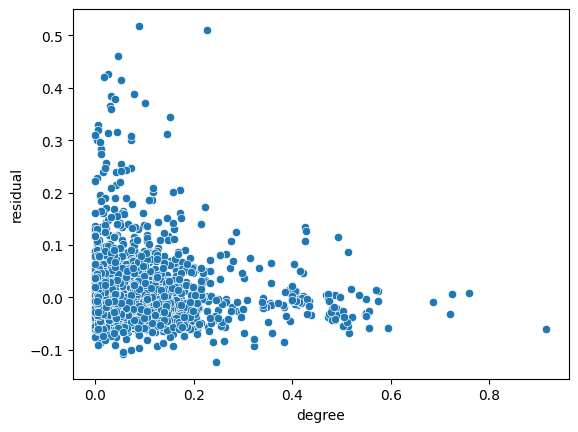

In [79]:
sns.scatterplot(x=X_test['degree'], y=df_test_rf['residual'])

<Axes: xlabel='birth_year', ylabel='residual'>

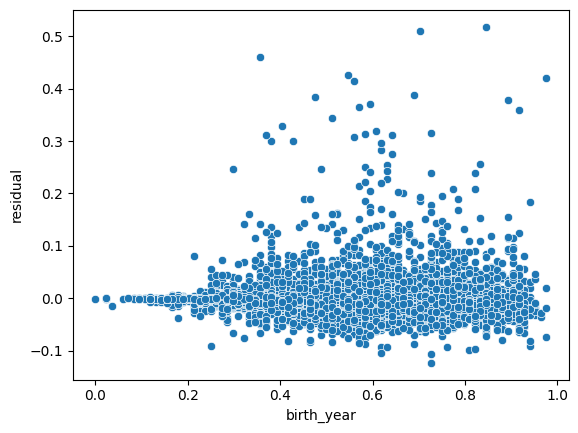

In [80]:
sns.scatterplot(x=X_test['birth_year'], y=df_test_rf['residual'])

<Axes: xlabel='betweenness', ylabel='residual'>

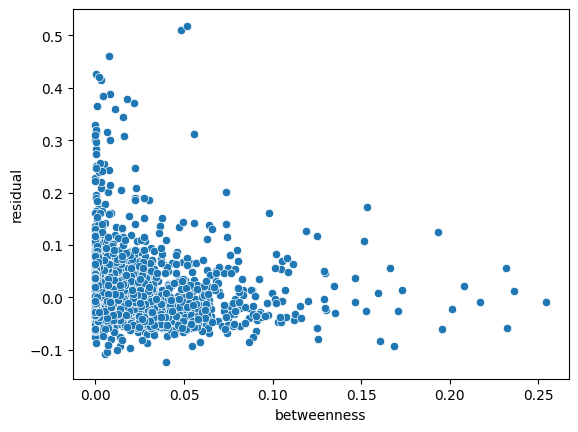

In [81]:
sns.scatterplot(x=X_test['betweenness'], y=df_test_rf['residual'])

Above are scatterplots for the three most important features of the RandomForestRegressor model. High error occured in samples with low degree and low betweenness. For birth year, the error was more evenly distributed across the feature distribution. The errors in prediction likely occured from the pull of degree and betweenness as these features had strong coefficients. 

In [82]:
df_test_rf.groupby('race')['residual'].mean().sort_values(ascending=False)

C:\Users\uprig\AppData\Local\Temp\ipykernel_62564\2626949007.py:1: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  df_test_rf.groupby('race')['residual'].mean().sort_values(ascending=False)


race
Black                             0.003478
Hispanic                          0.001436
White                            -0.000623
Native American/Alaskan Native   -0.001219
Asian/Pacific Islander           -0.005460
Name: residual, dtype: float64

In [83]:
df_test_rf.groupby('gender')['residual'].mean().sort_values(ascending=False)

C:\Users\uprig\AppData\Local\Temp\ipykernel_62564\3544038352.py:1: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  df_test_rf.groupby('gender')['residual'].mean().sort_values(ascending=False)


gender
M    0.001357
F   -0.002482
Name: residual, dtype: float64

Above is the mean error grouped by the race and gender of the officers. The error is highest for Black and Asian/Pacific Islander officers and lowest for white officers. 

Next, we will conduct error analysis on the best Linear Model. 

In [84]:
df_test_lm = data_df.iloc[test_idx].copy()
df_test_lm['pred_rate'] = best_reg_l2.predict(X_test)
df_test_lm['residual'] = df_test_lm['incident_rate'] - df_test_lm['pred_rate']
df_test_lm = df_test_lm.sort_values(by='residual',key=lambda x: x.abs(),ascending=False)
df_test_lm.head(3)[['UID','incident_rate','pred_rate', 'residual']]

,UID,incident_rate,pred_rate,residual
24050,124060,0.673086,0.117020,0.556066
16524,116529,0.681522,0.137149,0.544373
24202,124212,0.504356,0.051435,0.452921


<Axes: xlabel='degree', ylabel='residual'>

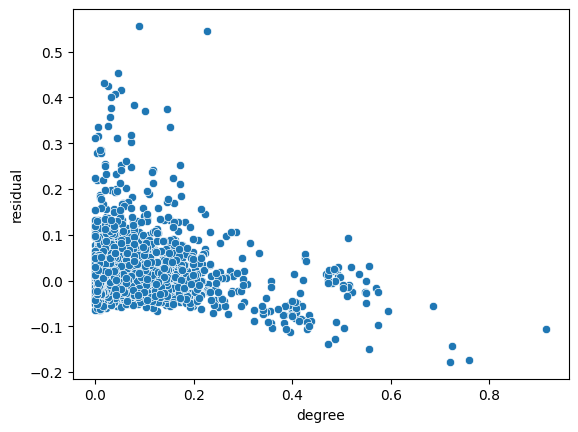

In [85]:
sns.scatterplot(x=X_test['degree'], y=df_test_lm['residual'])

<Axes: xlabel='betweenness', ylabel='residual'>

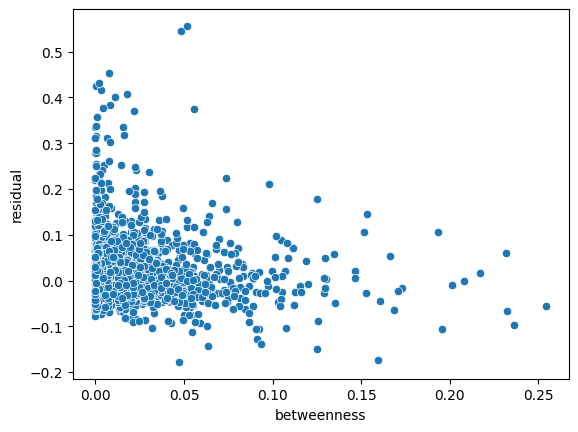

In [86]:
sns.scatterplot(x=X_test['betweenness'], y=df_test_lm['residual'])

<Axes: xlabel='eigenvector', ylabel='residual'>

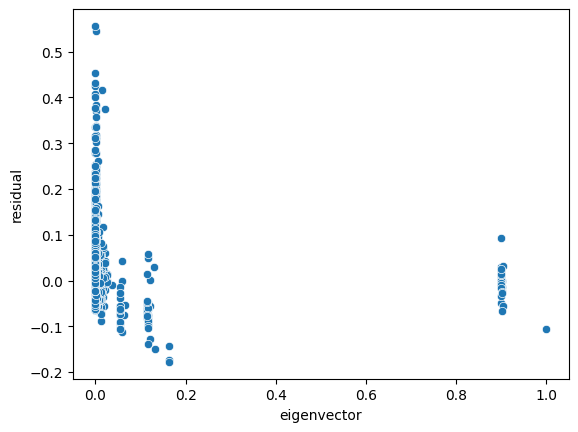

In [87]:
sns.scatterplot(x=X_test['eigenvector'], y=df_test_lm['residual'])

<Axes: xlabel='birth_year', ylabel='residual'>

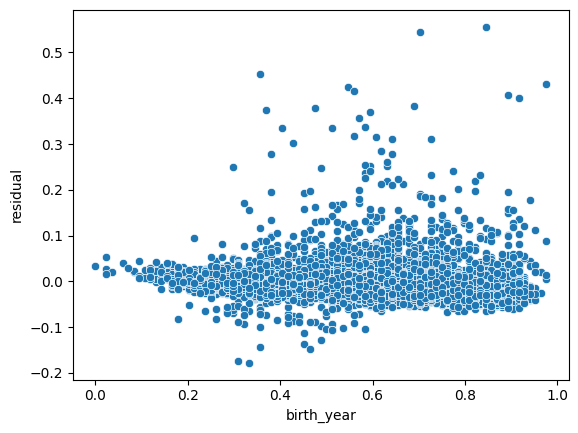

In [88]:
sns.scatterplot(x=X_test['birth_year'], y=df_test_lm['residual'])

Similarly to the RandomForestRegressor, high error occured in samples with low degree and low betweenness. Eigenvector centrality had a heavy skew of high error for the lowest values. For birth year, the error was more evenly distributed across the feature distribution. Again, the errors in prediction likely occured from the pull of degree and betweenness as these features had strong coefficients. 

In [89]:
df_test_lm.groupby('race')['residual'].mean().sort_values(ascending=False)

C:\Users\uprig\AppData\Local\Temp\ipykernel_62564\257991418.py:1: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  df_test_lm.groupby('race')['residual'].mean().sort_values(ascending=False)


race
Hispanic                          0.002287
White                             0.000903
Black                            -0.000096
Native American/Alaskan Native   -0.001298
Asian/Pacific Islander           -0.001818
Name: residual, dtype: float64

In [90]:
df_test_lm.groupby('gender')['residual'].mean().sort_values(ascending=False)

C:\Users\uprig\AppData\Local\Temp\ipykernel_62564\372026147.py:1: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  df_test_lm.groupby('gender')['residual'].mean().sort_values(ascending=False)


gender
M    0.000932
F    0.000541
Name: residual, dtype: float64

Above is the mean error grouped by the race and gender of the officers. For this model, the error is lower for both white and Black officers and higher for the other race categories. The mean error for gender is also lower under this model. 

Overall, the error patterns for both models were relatively similiar. This result is consistent with how both models performed similarly (similar R2 values) and had similar rankings of feature importance. It seems that the models are processing the feature information similary and so have predictions that are close to one another, both when they are right and when they are wrong. These models are a bit limited in explanatory power. It would be more compelling if we had a more complete social network that was not just based on the reports we have access to. 

Below, we conduct some error analysis for the worst model, Lasso. Again, we display scatterplots of the features of top importance. Birth_year and degree show similar patterns as the stronger models, though degree is a bit more sporatic, which reflects the weakness of this model. Clustering has the quite a lot of variance, so for the Lasso model, the importance of clustering is likely the culprit for poor predictions. The mean error for race and gender categories is higher than for Ridge, with lowest error for White and Native American/Alaskan Native race categories. 

In [91]:
df_test_lm2 = data_df.iloc[test_idx].copy()
df_test_lm2['pred_rate'] = best_reg_l1.predict(X_test)
df_test_lm2['residual'] = df_test_lm2['incident_rate'] - df_test_lm2['pred_rate']
df_test_lm2 = df_test_lm2.sort_values(by='residual',key=lambda x: x.abs(),ascending=False)
df_test_lm2.head(3)[['UID','incident_rate','pred_rate', 'residual']]

,UID,incident_rate,pred_rate,residual
16524,116529,0.681522,0.087871,0.593651
24050,124060,0.673086,0.087643,0.585443
24202,124212,0.504356,0.055435,0.448920


<Axes: xlabel='birth_year', ylabel='residual'>

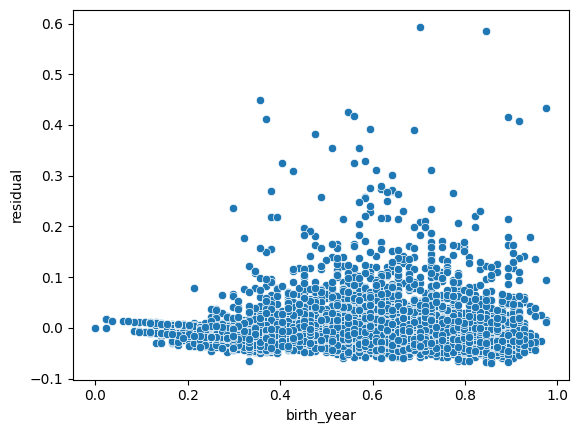

In [92]:
sns.scatterplot(x=X_test['birth_year'], y=df_test_lm2['residual'])

<Axes: xlabel='degree', ylabel='residual'>

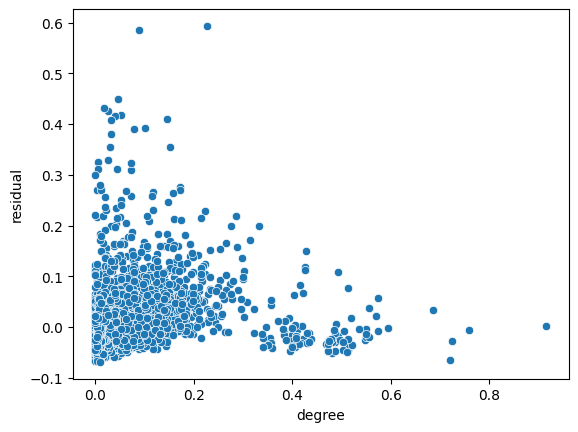

In [93]:
sns.scatterplot(x=X_test['degree'], y=df_test_lm2['residual'])

<Axes: xlabel='clustering', ylabel='residual'>

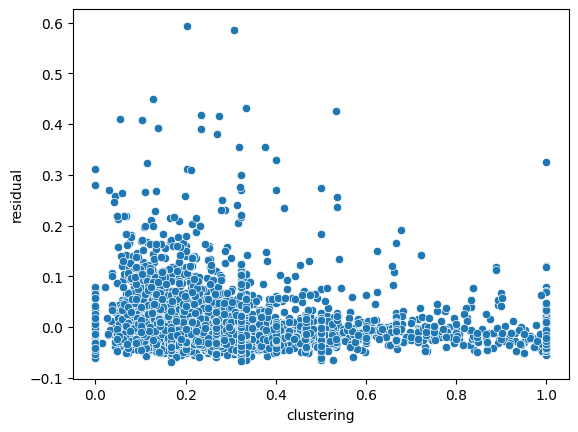

In [94]:
sns.scatterplot(x=X_test['clustering'], y=df_test_lm2['residual'])

In [95]:
df_test_lm2.groupby('race')['residual'].mean().sort_values(ascending=False)

C:\Users\uprig\AppData\Local\Temp\ipykernel_62564\2481764024.py:1: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  df_test_lm2.groupby('race')['residual'].mean().sort_values(ascending=False)


race
Hispanic                          0.004070
Black                             0.002863
Native American/Alaskan Native   -0.000582
White                            -0.000766
Asian/Pacific Islander           -0.005046
Name: residual, dtype: float64

In [96]:
df_test_lm2.groupby('gender')['residual'].mean().sort_values(ascending=False)

C:\Users\uprig\AppData\Local\Temp\ipykernel_62564\2779415207.py:1: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  df_test_lm2.groupby('gender')['residual'].mean().sort_values(ascending=False)


gender
M    0.002232
F   -0.004862
Name: residual, dtype: float64

## Model Evaluation

Now, we will evaluate model performance. We will calculate quantitative measures to review the variance and error for each model. We will calculate the R2 score, explained variance score, mean absolute error, and mean squared error. 

In [97]:
from sklearn.metrics import r2_score, explained_variance_score, mean_absolute_error, mean_squared_error

In [101]:
y_pred_dt = best_dt_reg.predict(X_test)
y_pred_rf = best_rf_reg.predict(X_test)
y_pred_ln = ln_reg.predict(X_test)
y_pred_l1 = best_reg_l1.predict(X_test)
y_pred_l2 = best_reg_l2.predict(X_test)

y_preds = {
    'DecisionTree': y_pred_dt,
    'RandomForest': y_pred_rf,
    'LinearRegression': y_pred_ln,
    'Lasso': y_pred_l1,
    'Ridge': y_pred_l2
}

In [102]:
# Create empty list to store results
results = []

for name, y_pred in y_preds.items():
    # Calculate metrics
    r2 = np.round(r2_score(y_test, y_pred), 2)
    evs = np.round(explained_variance_score(y_test, y_pred), 2)
    mae = np.round(mean_absolute_error(y_test, y_pred), 3)
    mse = np.round(mean_squared_error(y_test, y_pred), 4)
    
    # Append as dictionary
    results.append({
        'Model': name,
        'R2': r2,
        'Explained Variance': evs,
        'MAE': mae,
        'MSE': mse
    })

# Convert to DataFrame
df_results = pd.DataFrame(results)

print(df_results)

              Model    R2  Explained Variance    MAE     MSE
0      DecisionTree  0.34                0.37  0.023  0.0021
1      RandomForest  0.43                0.43  0.023  0.0018
2  LinearRegression  0.36                0.36  0.026  0.0021
3             Lasso  0.25                0.25  0.030  0.0024
4             Ridge  0.36                0.36  0.026  0.0021


The R2 score measures how the model's predictions compare to always predicting the mean. All five models do better than predicting the mean. Based on this metric, RandomForest is the strongest model and Lasso is the weakest. Lasso performed the worst likely because it shrinks some feature coefficients to zero. Therefore, Lasso is losing helpful predictive power from the features it makes zero and those features are meaningful to the model. Though RandomForest has the highest R2 value, for the purposes of interpreting, it is useful to know what the values for each feature would be, so the LinearRegression model would be preferred as it provides coefficients for all features without shrinking, while maintaining the higher R2 value (compared to Ridge). RandomForestRegressor is useful for having high accuracy of predicitons, but it is more difficult to interpret than LinearRegression. For example, with LinearRegression, we can clearly see that the largest coefficient (0.443483) reflects the strength of the effect of betweenness centrality on an officer's incident rate. 

Overall, the explained variance values are similar to the R2 values. This means that there is not much bias in the predictions. If there was bias, R2 could be lower than explained variance as R2 penalizes bias by comparing to the mean. Explained variance does not penalize bias if it is consistent across the data because it is measuring if the level of variance in the predictions is comparable to the true data. Only for the DecisionTreeRegressor is there a difference between R2 and explained variance. For DecisionTreeRegressor, there may be some bias in the predictions, which makes sense as this model is sensitive to data. If there is any noise in the data, the DecisionTree would have a different structure and have prediction that are more off compared to other models, such as the ensemble learning used in RandomForestRegressor. 

Mean absolute error shows the amount of error in the model. The tree-based models have slightly less error in prediction than the linear models, with Lasso having the largest error value. Mean squared error penalizes large errors due to the squaring. Overall, the models have similar MSE values so no model created more large errors than the rest. 

If the priority in model selection is lessening error, then the best model would be RandomForestRegressor as it has the lower absolute error value and the higher R2 value of the two tree-based models. However, if intepretation is the goal, LinearRegression is better since it is easier to interpret while still having a high R2 value and a low error value (comparatively).  Since we care about interpretability, LinearRegression is the best model for this project. 

# Discussion of Results and Conclusion

As explained above, the best model for the research question depends on the goals. If we want to use this model in order to predict if an officer is likely to be involved in misconduct, it would be best to use the RandomForestRegressor since this model has the highest R2 value and lowest absolute error value, which means this model is most accurate in its predictions. However, if our goal for this machine learning tasks is to determine which features have the most predictive power in determining rate of misconduct, we want to use linear models, such as LinearRegression and Ridge, since these have coefficients that can be interpreted. Since LinearRegression has no shrinking, we will interpret the coefficients of this model as it demonstrates the direct relationship between the features and the target variable of rate of misconduct. 

The largest coefficient (0.443) is on the betweenness centrality feature, meaning that a high betweenness centrality leads to a .443 unit increase in the rate of misconduct. Similarly, degree centrality increases rate misconduct at a rate of .223 units. This means that an officer being connected to a high number of other officers and acting as a "broker" between other officers is predictive of a higher rate of misconduct. In contrast, the third largest coefficient is negative and shows that eigenvector centrality, which measures being central to the social network in terms of being connected to other central players, causes a decrease in rate of misconduct. This result means that knowing prominent officers has a negative effect on rate of misconduct. 

Considering the categorical features, if an officer has been disciplined for an event in the past, there is a positive effect on rate of misconduct and a negative effect if they have never been disciplined. One possible interpretation for this trend is that officers who are disciplined have a higher rate of misconduct because officers are only disciplined if misconduct is a pattern or they are involved in particularly bad incidents. This could lead to a positive correlation between being disiplined and a high rate of misconduct. This conclusion leads to questions on the efficacy of punishment if officers still have high rates of misconduct. Another study could look into the timing between the discipline and misconduct cases to find patterns there. 

For rank, the largest coefficient is for police officer and shows that there is a positive effect on the rate of misconduct. This conclusion reflects how police officers interact with civilians the most and so are often in the position for complaints to be raised against them. Captain, Lieutenant, and Commander are the highest ranks and have a negative relationship with rate of misconduct which supports this conclusion. Hopefully, this also means that officers who engage in misconduct do not often move up the ranks. For gender, female has a negative effect on rate of misconduct and male has a positive effect. For race, all of the coefficients are quite small, with Black and Native American/Alaskan Native as positive and White, Hispanic, and Asian/Pacific Islander as negative. 

One possible issue with the data in being able to answer the research question is that the rate of misconduct is calculated based on complaints filed against officers. This is not a true rate of misconduct because it only includes what has been reported. There is selection bias here. Civilians may be more likely to report officers of certain demographics. Civilians also may be more likely to report certain types of misconduct, while other misconduct is left unreported. For these reasons, the target variable is an inaccurate measure of misconduct, though it does provide a reasonable substitute for something that is difficult to gather data on. 

Another issue with the data is that the network features and the target variable are calculated from the same set of CPD documents. Though the social network was created from both complaints and tactical force reports, and therefore includes incidents that are not classified as misconduct (for the purposes of this project), there is still some relationship between these network characteristics and the number of complaints. The edges for an officer in the network will be larger due to the tactical force reports, but it is still related to the share of edges that come from the number of complaints, which is used in the target variable. In the future, this model would be more accurate if the social network could be created from different information, such as snowball sampling the officers, using social media connections, or other measures. Then the social network characteristics would not be related to the target variable as strongly. This is a process that is part of the monitoring stage of the machine learning pipeline as the new data would then be cleaned to retrain the model. 

In conclusion, network characteristics are the most useful for predicting CPD officers rate of misconduct. Categorical categories, such as rank and discipline, can also be interpretted to have a relationship with rate of misconduct, though the coefficients are smaller. 